In [2]:
import numpy as np
from scipy.stats import unitary_group

import random
from random import choices

from functools import partial
from itertools import product, combinations
from opt_einsum import contract

import qutip as qt

import jax
import jax.numpy as jnp

import time
import os

from circuits import maxEntangle_state, CQstate
from circuits import seqModel_RA_vec, seqModel_RAmc, seqModel_CQ_RA_vec, seqModel_CQ_RAmc, seqModelnoReset_RAmc
from circuits import seqModelTraceOut_RA_vec, seqModelTraceOutMaxMix_RA_vec

from information_measure import psiR_purity_vec, psiR_vNEntropy_vec, MI_rhoRA_vec, MIr2_rhoRA_vec, holevoInfo_vec, rho_vNEntropy
from haar_theory import avgS2, MIR2_traceout, MIR2_traceout_MM

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib import rc
from matplotlib.gridspec import GridSpec
rc('text', usetex=True)
rc('font', size=25)
rc('axes', linewidth=3)
rc('text.latex', preamble=r'\usepackage{amsfonts}')
rc('text.latex', preamble=r'\usepackage{bm}')

# sequential model conditional mutual information calculation

In [ ]:
# Bell-input, exact calculation
num = 50

Na = 5
Nb = 1

probs = []
vnEntropy = []
purities = []
for t in range(1, 15//Nb+1):
    t0 = time.time()
    zs = np.array(list(product(range(2**Nb), repeat=t))).astype(np.int8)
    
    each_pr = jnp.zeros((num, 2**(Nb*t)))
    each_vn = jnp.zeros((num, 2**(Nb*t)))
    each_pu = jnp.zeros((num, 2**(Nb*t)))
    for j in range(num):
        np.random.seed(1+j)
        Us = unitary_group.rvs(dim=2**(Na+Nb), size=t).reshape(t, 2**(Na+Nb), 2**(Na+Nb))
        psi_RA = maxEntangle_state(Na).full().squeeze()
        
        res = seqModel_RA_vec(zs, Us, psi_RA, Na, Nb, t)
        
        each_pr = each_pr.at[j].set(jnp.product(res[0], axis=1))
        each_vn = each_vn.at[j].set(psiR_vNEntropy_vec(res[1], Na))
        each_pu = each_pu.at[j].set(psiR_purity_vec(res[1], Na))
    
    probs.append(each_pr)
    vnEntropy.append(each_vn)
    purities.append(each_pu)
    print(f'Nb={Nb}, step={t}, time={(time.time() - t0):.2f}')

path = f'data/seqModel/Na{Na}/monitored/bell/'
if not os.path.exists(path):
    os.makedirs(path)

np.savez(os.path.join(path, f'probs_Na{Na}Nb{Nb}_ex.npz'), *probs)
np.savez(os.path.join(path, f'vnEntropy_Na{Na}Nb{Nb}_ex.npz'), *vnEntropy)
np.savez(os.path.join(path, f'purity_Na{Na}Nb{Nb}_ex.npz'), *purities)

In [ ]:
# bell-input monte-carlo sampling
num = 50
Na = 5
Nb = 1

mc_num = int(4e4)

vnEntropy = []
purities = []
for t in [20, 30, 40, 50, 60, 70]:
    t0 = time.time()
    
    each_vn = jnp.zeros((num, mc_num))
    each_pu = jnp.zeros((num, mc_num))
    for j in range(num):
        np.random.seed(1+j)
        Us = unitary_group.rvs(dim=2**(Na+Nb), size=t).reshape(t, 2**(Na+Nb), 2**(Na+Nb))
        psi_RA = maxEntangle_state(Na).full().squeeze()

        res = seqModel_RAmc(Us, psi_RA, Na, Nb, t, mc_num)
        
        each_vn = each_vn.at[j].set(psiR_vNEntropy_vec(res, Na))
        each_pu = each_pu.at[j].set(psiR_purity_vec(res, Na))
    
    vnEntropy.append(each_vn)
    purities.append(each_pu)
    print(f'Nb={Nb}, step={t}, time={(time.time() - t0):.2f}')

path = f'data/seqModel/Na{Na}/monitored/bell/'
np.save(os.path.join(path, f'vnEntropy_Na{Na}Nb{Nb}_mc.npy'), np.stack(vnEntropy))
np.save(os.path.join(path, f'purity_Na{Na}Nb{Nb}_mc.npy'), np.stack(purities))

In [ ]:
# collect result
Na = 6
Nb = 1
t = [20, 30, 40, 50, 75, 100, 125, 150]
path = f'data/seqModel/Na{Na}/monitored/bell/'
prob = np.load(os.path.join(path, f'probs_Na{Na}Nb{Nb}_ex.npz'))
vnEn = np.load(os.path.join(path, f'vnEntropy_Na{Na}Nb{Nb}_ex.npz'))

avgMI = [2*Na*np.ones(20)]
for j in range(15):
    avgMI.append(2*(prob[f'arr_{j}']*vnEn[f'arr_{j}']).sum(1))

x = np.load(os.path.join(path, f'vnEntropy_Na{Na}Nb{Nb}_mc.npy'))
avgMI.extend(2*x.mean(2))

avgMI = np.stack(avgMI)

np.savez(f'data/seqModel/Na{Na}/monitored/bell/avgMI_Na{Na}Nb{Nb}', t=np.hstack((np.arange(16), t)), MI=avgMI)

In [ ]:
# non-bell pure input, exact calculation
num = 50

Na = 5
Nb = 1

probs = []
vnEntropy = []
purities = []

delta = 0
for t in range(1, 15//Nb+1):
    t0 = time.time()
    zs = np.array(list(product(range(2**Nb), repeat=t))).astype(np.int8)
    
    each_pr = jnp.zeros((num, 2**(Nb*t)))
    each_vn = jnp.zeros((num, 2**(Nb*t)))
    each_pu = jnp.zeros((num, 2**(Nb*t)))
    for j in range(num):
        np.random.seed(1+j)
        Us = unitary_group.rvs(dim=2**(Na+Nb), size=t).reshape(t, 2**(Na+Nb), 2**(Na+Nb))
        psi_RA = qt.rand_ket_haar(2**(2*Na), dims=[[2]*(2*Na), [1]*(2*Na)], seed=2025)
        psi_RA = (psi_RA + delta*qt.basis([2]*(2*Na), [0]*(2*Na))).unit()
        
        res = seqModel_RA_vec(zs, Us, psi_RA.full().squeeze(), Na, Nb, t)
        
        each_pr = each_pr.at[j].set(jnp.product(res[0], axis=1))
        each_vn = each_vn.at[j].set(psiR_vNEntropy_vec(res[1], Na))
        each_pu = each_pu.at[j].set(psiR_purity_vec(res[1], Na))
    
    probs.append(each_pr)
    vnEntropy.append(each_vn)
    purities.append(each_pu)
    print(f'Nb={Nb}, step={t}, time={(time.time() - t0):.2f}')

path = f'data/seqModel/Na{Na}/monitored/nonBell/delta{delta}'
if not os.path.exists(path):
    os.makedirs(path)

np.savez(os.path.join(path, f'probs_Na{Na}Nb{Nb}_del{delta}_ex.npz'), *probs)
np.savez(os.path.join(path, f'vnEntropy_Na{Na}Nb{Nb}_del{delta}_ex.npz'), *vnEntropy)
np.savez(os.path.join(path, f'purity_Na{Na}Nb{Nb}_del{delta}_ex.npz'), *purities)

In [ ]:
# non-bell pure input, monte-carlo
num = 20

Na = 5
Nb = 1

mc_num = int(4e4)

vnEntropy = []
purities = []
delta = 0
for t in [20, 30, 40, 50]:
    t0 = time.time()
    
    each_vn = jnp.zeros((num, mc_num))
    each_pu = jnp.zeros((num, mc_num))
    for j in range(num):
        np.random.seed(1+j)
        Us = unitary_group.rvs(dim=2**(Na+Nb), size=t).reshape(t, 2**(Na+Nb), 2**(Na+Nb))
        psi_RA = qt.rand_ket_haar(2**(2*Na), dims=[[2]*(2*Na), [1]*(2*Na)], seed=2025)
        psi_RA = (psi_RA + delta*qt.basis([2]*(2*Na), [0]*(2*Na))).unit()

        res = seqModel_RAmc(Us, psi_RA.full().squeeze(), Na, Nb, t, mc_num)
        
        each_vn = each_vn.at[j].set(psiR_vNEntropy_vec(res, Na))
        each_pu = each_pu.at[j].set(psiR_purity_vec(res, Na))
    
    vnEntropy.append(each_vn)
    purities.append(each_pu)
    print(f'Nb={Nb}, step={t}, time={(time.time() - t0):.2f}')

path = f'data/seqModel/Na{Na}/monitored/nonBell/delta{delta}'
if not os.path.exists(path):
    os.makedirs(path)

np.save(os.path.join(path, f'vnEntropy_Na{Na}Nb{Nb}_del{delta}_mc.npy'), np.stack(vnEntropy))
np.save(os.path.join(path, f'purity_Na{Na}Nb{Nb}_del{delta}_mc.npy'), np.stack(purities))

In [268]:
# collect result
Na = 5
Nb = 1
deltas = [0, 0.65, 1, 1.25, 1.55, 2, 2.7]
path = f'data/seqModel/Na{Na}/monitored/nonBell/'
for delta in deltas:
    prob = np.load(os.path.join(path, f'delta{delta}/probs_Na{Na}Nb{Nb}_del{delta}_ex.npz'))
    vnEn = np.load(os.path.join(path, f'delta{delta}/vnEntropy_Na{Na}Nb{Nb}_del{delta}_ex.npz'))

    psi_RA = qt.rand_ket_haar(2**(2*Na), dims=[[2]*(2*Na), [1]*(2*Na)], seed=2025)
    psi_RA = (psi_RA + delta*qt.basis([2]*(2*Na), [0]*(2*Na))).unit()
    I0 = qt.entropy_mutual(qt.ket2dm(psi_RA), range(Na), range(Na), base=2)
    avgMI = [I0 * np.ones(20)]
    for j in range(15):
        avgMI.append(2*(prob[f'arr_{j}']*vnEn[f'arr_{j}']).sum(1))

    vnEn = np.load(os.path.join(path, f'delta{delta}/vnEntropy_Na{Na}Nb{Nb}_del{delta}_mc.npy'))
    vnEn1 = np.load(os.path.join(path, f'delta{delta}/vnEntropy_Na{Na}Nb{Nb}_del{delta}_mc1.npy'))
    avgMI.append(2*vnEn.mean(2))
    avgMI.append(2*vnEn1.mean(2))
    avgMI = np.vstack(avgMI)
    np.savez(os.path.join(path, f'delta{delta}/avgMI_Na{Na}Nb{Nb}_del{delta}'), 
             t=np.hstack((np.arange(16), np.arange(2, 6)*10, [75, 100, 150, 200])), MI=avgMI)

In [ ]:
# CQ state input, exact calculation
num = 10

Nr = 5
Na = 5
Nb = 1

probs = []
MI = []

# prepare CQ state
delta = 0
V = qt.rand_unitary_haar(2**Na, seed=2025)
psis_A = V.full().T[:2**Nr]
psis_A += delta * qt.basis(2**Na, 0).full().squeeze()
psis_A /= np.linalg.norm(psis_A, axis=1)[:, np.newaxis]

# calculate dynamics
for t in range(1, 15//Nb+1):
    t0 = time.time()
    zs = np.array(list(product(range(2**Nb), repeat=t))).astype(np.int8)

    each_pr = np.zeros((num, 2**(Nb*t)))
    each_mi = np.zeros((num, 2**(Nb*t)))

    for j in range(num):
        np.random.seed(1+j)
        Us = unitary_group.rvs(dim=2**(Na+Nb), size=t).reshape(t, 2**(Na+Nb), 2**(Na+Nb))
        
        res = seqModel_CQ_RA_vec(zs, Us, psis_A, Na, Nb, t)
        
        each_pr[j] = jnp.product(res[0], axis=1)
        each_mi[j] = holevoInfo_vec(res[1], res[2])

    probs.append(each_pr)
    MI.append(each_mi)
    print(f'Na={Na}, Nb={Nb}, step={t}, time={(time.time() - t0):.2f}')

path = f'data/seqModel/Na{Na}/monitored/CQ/delta{delta}/'
if not os.path.exists(path):
    os.makedirs(path)

np.savez(os.path.join(path, f'probs_Na{Na}Nb{Nb}_del{delta}_ex.npz'), *probs)
np.savez(os.path.join(path, f'MI_Na{Na}Nb{Nb}_del{delta}_ex.npz'), *MI)


In [ ]:
# CQ state input, monte-carlo
num = 10

Nr = 5
Na = 5
Nb = 1

MI = []

mc_num = int(1e4)

# prepare CQ state
delta = 0
V = qt.rand_unitary_haar(2**Na, seed=2025)
psis_A = V.full().T[:2**Nr]
psis_A += delta * qt.basis(2**Na, 0).full().squeeze()
psis_A /= np.linalg.norm(psis_A, axis=1)[:, np.newaxis]

# calculate dynamics
for t in [1]:
    t0 = time.time()

    each_mi = np.zeros((num, mc_num))
    for j in range(num):
        np.random.seed(1+j)
        Us = unitary_group.rvs(dim=2**(Na+Nb), size=t).reshape(t, 2**(Na+Nb), 2**(Na+Nb))
        
        res = seqModel_CQ_RAmc(Us, psis_A, Na, Nb, t, mc_num)
        
        each_mi[j] = holevoInfo_vec(res[0], res[1])

    MI.append(each_mi)
    print(f'Na={Na}, Nb={Nb}, step={t}, time={(time.time() - t0):.2f}')

path = f'data/seqModel/Na{Na}/monitored/CQ/delta{delta}/'
if not os.path.exists(path):
    os.makedirs(path)

np.save(os.path.join(path, f'MI_Na{Na}Nb{Nb}_del{delta}_mc.npy'), np.stack(MI))

In [232]:
# collect result
num = 10
Nr = 5
Na = 5
Nb = 1
deltas = [0, 0.74, 1.15, 1.7]
path = f'data/seqModel/Na{Na}/monitored/CQ/'
cc = 0
for delta in deltas:
    prob = np.load(os.path.join(path, f'delta{delta}/probs_Na{Na}Nb{Nb}_del{delta}_ex.npz'))
    MI = np.load(os.path.join(path, f'delta{delta}/MI_Na{Na}Nb{Nb}_del{delta}_ex.npz'))

    V = qt.rand_unitary_haar(2**Na, seed=2025)
    psis_A = V.full().T[:2**Nr]
    psis_A += delta * qt.basis(2**Na, 0).full().squeeze()
    psis_A /= np.linalg.norm(psis_A, axis=1)[:, np.newaxis]

    rho = contract('bi,bj->bij', psis_A, psis_A.conj()).mean(0)
    avgMI = [rho_vNEntropy(rho)*np.ones(num)]
    
    for j in range(15):
        avgMI.append((prob[f'arr_{j}'] * MI[f'arr_{j}']).sum(1))

    each = np.load(os.path.join(path, f'delta{delta}/MI_Na{Na}Nb{Nb}_del{delta}_mc.npy'))
    each1 = np.load(os.path.join(path, f'delta{delta}/MI_Na{Na}Nb{Nb}_del{delta}_mc1.npy'))

    avgMI.append(each.mean(2))
    avgMI.append(each1.mean(2))
    
    avgMI = np.vstack(avgMI)
    np.savez(os.path.join(path, f'delta{delta}/avgMI_Na{Na}Nb{Nb}_del{delta}'),
             t=np.hstack((np.arange(16), np.arange(2, 6)*10, [75, 100, 150, 200])), MI=avgMI) 

# sequential model uncondtional mutual information calculation

In [ ]:
# bell input
num = 50
Na = 5
Nb = 1

MI = [2*Na*np.ones(num)]
MI_r2 = [2*Na*np.ones(num)]
for t in range(1, 16):
    t0 = time.time()

    Us = []
    for j in range(num):
        np.random.seed(1+j)
        Us.append(unitary_group.rvs(dim=2**(Na+Nb), size=t).reshape(t, 2**(Na+Nb), 2**(Na+Nb)))
    Us = jnp.stack(Us)
    
    res = seqModelTraceOut_RA_vec(Us, Na, Nb, t)
    
    MI.append(MI_rhoRA_vec(res, Na))
    MI_r2.append(MIr2_rhoRA_vec(res, Na))

    print(f'Nb={Nb}, step={t}, time={(time.time() - t0):.2f}')

path = f'data/seqModel/Na{Na}/traceout/bell'
if not os.path.exists(path):
    os.makedirs(path)

np.save(os.path.join(path, f'MI_Na{Na}Nb{Nb}_traceout.npy'), np.stack(MI))
np.save(os.path.join(path, f'MIr2_Na{Na}Nb{Nb}_traceout.npy'), np.stack(MI_r2))

In [ ]:
# non-bell input
num = 20
Na = 4
Nb = 1

delta = 17
psi_RA = qt.rand_ket_haar(2**(2*Na), dims=[[2]*(2*Na), [1]*(2*Na)], seed=2025)
psi_RA = (psi_RA + delta*qt.basis([2]*(2*Na), [0]*(2*Na))).unit()
rho0_RA = qt.ket2dm(psi_RA)

MI = [qt.entropy_mutual(rho0_RA, range(Na), range(Na, 2*Na), base=2)*np.ones(num)]
MI_r2 = []

for t in range(1, 16):
    t0 = time.time()

    Us = []
    for j in range(num):
        np.random.seed(1+j)
        Us.append(unitary_group.rvs(dim=2**(Na+Nb), size=t).reshape(t, 2**(Na+Nb), 2**(Na+Nb)))
    Us = jnp.stack(Us)
    
    res = seqModelTraceOut_RA_vec(Us, rho0_RA.full(), Na, Nb, t)
    
    MI.append(MI_rhoRA_vec(res, Na))
    MI_r2.append(MIr2_rhoRA_vec(res, Na))

    print(f'Nb={Nb}, step={t}, time={(time.time() - t0):.2f}')

path = f'data/seqModel/Na{Na}/traceout/nonBell/delta{delta}'
if not os.path.exists(path):
    os.makedirs(path)

np.save(os.path.join(path, f'MI_Na{Na}Nb{Nb}_del{delta}_traceout.npy'), np.stack(MI))
np.save(os.path.join(path, f'MIr2_Na{Na}Nb{Nb}_del{delta}_traceout.npy'), np.stack(MI_r2))

In [ ]:
# CQ state input
num = 10
Na = 4
Nr = Na
Nb = 1

# prepare CQ state
delta = 17.3
psis = []
for i in range(2**Nr):
    bin_i = list(np.binary_repr(i, width=Na))
    bin_i = [int(x) for x in bin_i]
    basis_A = qt.basis([2]*Na, bin_i)
    V = qt.rand_unitary_haar(2**Na, [[2]*Na, [2]*Na], seed=2025)
    state_A = V * basis_A

    state_A = (state_A + delta*qt.basis([2]*Na, [0]*Na)).unit()
    psis.append(state_A)
rho0_RA = CQstate(psis, Nr)

MI = [qt.entropy_mutual(rho0_RA, range(Na), range(Na, 2*Na), base=2)*np.ones(num)]
MI_r2 = []
for t in range(1, 16):
    t0 = time.time()

    Us = []
    for j in range(num):
        np.random.seed(1+j)
        Us.append(unitary_group.rvs(dim=2**(Na+Nb), size=t).reshape(t, 2**(Na+Nb), 2**(Na+Nb)))
    Us = jnp.stack(Us)
    
    res = seqModelTraceOut_RA_vec(Us, rho0_RA.full(), Na, Nb, t)
    
    MI.append(MI_rhoRA_vec(res, Na))
    MI_r2.append(MIr2_rhoRA_vec(res, Na))

    print(f'Nb={Nb}, step={t}, time={(time.time() - t0):.2f}')

path = f'data/seqModel/Na{Na}/traceout/CQ/delta{delta}'
if not os.path.exists(path):
    os.makedirs(path)

np.save(os.path.join(path, f'MI_Na{Na}Nb{Nb}_del{delta}_traceout.npy'), np.stack(MI))
np.save(os.path.join(path, f'MIr2_Na{Na}Nb{Nb}_del{delta}_traceout.npy'), np.stack(MI_r2))

# Without reset calculation

## conditional mutual information

In [ ]:
num = 50
Na = 3
Nb = 1

mc_num = int(4e4)

vnEntropy = []
for t in range(1, 16):
    t0 = time.time()
    
    each_vn = jnp.zeros((num, mc_num))
    for j in range(num):
        np.random.seed(1+j)
        Us = unitary_group.rvs(dim=2**(Na+Nb), size=t).reshape(t, 2**(Na+Nb), 2**(Na+Nb))
        
        res = seqModelnoReset_RAmc(Us, Na, Nb, t, mc_num)
        
        each_vn = each_vn.at[j].set(psiR_vNEntropy_vec(res, Na))
    
    vnEntropy.append(each_vn)
    print(f'Nb={Nb}, step={t}, time={(time.time() - t0):.2f}')
    
np.save(f'data/seqModel/Na{Na}/noReset/vnEntropy_Na{Na}Nb{Nb}_mc.npy', np.stack(vnEntropy))

## unconditional mutual information

In [63]:
# without reset
num = 50
Na = 3
Nb = 1

MI = []
MI_r2 = []
for t in range(1, 7):
    t0 = time.time()

    Us = []
    for j in range(num):
        np.random.seed(1+j)
        Us.append(unitary_group.rvs(dim=2**(Na+Nb), size=t).reshape(t, 2**(Na+Nb), 2**(Na+Nb)))
    Us = jnp.stack(Us)
    
    res = seqModelTraceOutnoReset_RA_vec(Us, Na, Nb, t)
    
    MI.append(MI_rhoRA_vec(res, Na))
    MI_r2.append(MIr2_rhoRA_vec(res, Na))

    print(f'Nb={Nb}, step={t}, time={(time.time() - t0):.2f}')

path = f'data/seqModel/Na{Na}/noReset'
if not os.path.exists(path):
    os.makedirs(path)

np.save(f'data/seqModel/Na{Na}/noReset/MI_Na{Na}Nb{Nb}_traceout.npy', np.stack(MI))
np.save(f'data/seqModel/Na{Na}/noReset/MIr2_Na{Na}Nb{Nb}_traceout.npy', np.stack(MI_r2))

Nb=1, step=1, time=0.17
Nb=1, step=2, time=0.28
Nb=1, step=3, time=0.41
Nb=1, step=4, time=0.53
Nb=1, step=5, time=0.66
Nb=1, step=6, time=0.77


In [16]:
# without reset + maximally mixed
num = 50
Na = 4
Nb = 2

MI = []
MI_r2 = []
for t in range(1, 15//Nb+1):
    t0 = time.time()

    Us = []
    for j in range(num):
        np.random.seed(1+j)
        Us.append(unitary_group.rvs(dim=2**(Na+Nb), size=t).reshape(t, 2**(Na+Nb), 2**(Na+Nb)))
    Us = jnp.stack(Us)
    
    res = seqModelTraceOutMaxMix_RA_vec(Us, Na, Nb, t)
    
    MI.append(MI_rhoRA_vec(res, Na))
    MI_r2.append(MIr2_rhoRA_vec(res, Na))
    print(f'Nb={Nb}, step={t}, time={(time.time() - t0):.2f}')

np.save(f'data/seqModel/Na{Na}/noReset/MI_Na{Na}Nb{Nb}_traceoutMM.npy', np.stack(MI))
np.save(f'data/seqModel/Na{Na}/noReset/MIr2_Na{Na}Nb{Nb}_traceoutMM.npy', np.stack(MI_r2))

Nb=2, step=1, time=10.39
Nb=2, step=2, time=13.19
Nb=2, step=3, time=15.60
Nb=2, step=4, time=17.80
Nb=2, step=5, time=20.29
Nb=2, step=6, time=22.48
Nb=2, step=7, time=24.91


## average mutual information with identical haar unitary

In [ ]:
# von-Neumann entropy and purity with same unitary (exact calculation)
num = 50

Na = 5
Nb = 1

# exact calculation
probs = []
vnEntropy = []
purities = []
for t in range(1, 15//Nb + 1):
    t0 = time.time()
    zs = np.array(list(product(range(2**Nb), repeat=t))).astype(np.int8)
    
    each_pr = jnp.zeros((num, 2**(Nb*t)))
    each_vn = jnp.zeros((num, 2**(Nb*t)))
    each_pu = jnp.zeros((num, 2**(Nb*t)))
    for j in range(num):
        np.random.seed(1+j)
        U = unitary_group.rvs(dim=2**(Na+Nb))
        Us = jnp.array([U]*t)

        res = seqModel_RA_vec(zs, Us, Na, Nb, t)
        
        each_pr = each_pr.at[j].set(jnp.product(res[0], axis=1))
        each_vn = each_vn.at[j].set(psiR_vNEntropy_vec(res[1], Na))
        each_pu = each_pu.at[j].set(psiR_purity_vec(res[1], Na))

    probs.append(each_pr)
    vnEntropy.append(each_vn)
    purities.append(each_pu)
    print(f'Nb={Nb}, step={t}, time={(time.time() - t0):.2f}')

path = f'data/seqModel/Na{Na}/sameU'
if not os.path.exists(path):
    os.makedirs(path)
    
np.savez(f'data/seqModel/Na{Na}/sameU/probs_Na{Na}Nb{Nb}_ex.npz', *probs)
np.savez(f'data/seqModel/Na{Na}/sameU/vnEntropy_Na{Na}Nb{Nb}_ex.npz', *vnEntropy)
np.savez(f'data/seqModel/Na{Na}/sameU/purity_Na{Na}Nb{Nb}_ex.npz', *purities)

In [ ]:
num = 50
Na = 5
Nb = 1

mc_num = int(4e4)

vnEntropy = []
purities = []

for t in [20, 30, 40, 50]:
    t0 = time.time()
    
    each_vn = jnp.zeros((num, mc_num))
    each_pu = jnp.zeros((num, mc_num))
    for j in range(num):
        np.random.seed(1+j)
        U = unitary_group.rvs(dim=2**(Na+Nb))
        Us = jnp.array([U]*t)
        
        res = seqModel_RAmc(Us, Na, Nb, t, mc_num)
        
        each_vn = each_vn.at[j].set(psiR_vNEntropy_vec(res, Na))
        each_pu = each_pu.at[j].set(psiR_purity_vec(res, Na))
    
    print(f'Nb={Nb}, step={t}, time={(time.time() - t0):.2f}')

    np.save(f'data/seqModel/Na{Na}/sameU/vnEntropy_Na{Na}Nb{Nb}_t{t}_mc.npy', each_vn)
    np.save(f'data/seqModel/Na{Na}/sameU/purity_Na{Na}Nb{Nb}_t{t}_mc.npy', each_pu)

In [101]:
Na = 2
Nb = 1

prob = np.load(f'data/seqModel/Na{Na}/sameU/probs_Na{Na}Nb{Nb}_ex.npz')
vnEn = np.load(f'data/seqModel/Na{Na}/sameU/vnEntropy_Na{Na}Nb{Nb}_ex.npz')

avgS1 = [Na*np.ones(50)]
for j in range(15):
    avgS1.append((prob[f'arr_{j}']*vnEn[f'arr_{j}']).sum(1))
avgS1 = np.stack(avgS1)
np.save(f'data/seqModel/Na{Na}/sameU/avgS1_Na{Na}Nb{Nb}_ex.npy', avgS1)

## average mutual information dynamics with Ising-like Hamiltonian

In [ ]:
def IsingHamiltonian(N, seed):
    np.random.seed(seed)
    hx0_vec_all = 1.0 + 0.3*np.random.randn(N)
    hz0_vec_all = 0.0 + 0.3*np.random.randn(N)

    J_vec_all = 0 + 1.0*np.random.rand(N*(N-1)//2)
    
    Xs = []
    Zs = []
    for i in range(N):
        X = qt.tensor([qt.sigmax() if k==i else qt.qeye(2) for k in range(N)])
        Xs.append(X)
        Z = qt.tensor([qt.sigmaz() if k==i else qt.qeye(2) for k in range(N)])
        Zs.append(Z)
    
    H = 0
    for i in range(N):
        H += hx0_vec_all[i] * Xs[i]
        H += hz0_vec_all[i] * Zs[i]
    
    for cc, (i, j) in enumerate(combinations(range(N), 2)):
        H += J_vec_all[cc] * Zs[i] * Zs[j]
    
    return H

In [ ]:
# von-Neumann entropy and purity (exact calculation) using Ising Hamiltonian
t_evo = 50
Na = 5
Nb = 1

# exact calculation
probs = []
vnEntropy = []
purities = []
for t in range(1, 15//Nb+1):
    t0 = time.time()
    zs = np.array(list(product(range(2**Nb), repeat=t))).astype(np.int8)
    
    Us = []
    for tt in range(t):
        H0 = IsingHamiltonian(Na + Nb, 1 + tt)
        U0  = (- 1j * t_evo * H0).expm()
        Us.append(U0.full())
    Us = jnp.stack(Us)

    res = seqModel_RA_vec(zs, Us, Na, Nb, t)
    each_pr = jnp.prod(res[0], axis=1)
    
    each_vn = psiR_vNEntropy_vec(res[1], Na)
    each_pu = psiR_purity_vec(res[1], Na)

    probs.append(each_pr)
    vnEntropy.append(each_vn)
    purities.append(each_pu)
    print(f'Nb={Nb}, step={t}, time={(time.time() - t0):.2f}')
    
np.savez(f'data/seqModel/Na{Na}/probsIsing_Na{Na}Nb{Nb}_ex.npz', *probs)
np.savez(f'data/seqModel/Na{Na}/vnEntropyIsing_Na{Na}Nb{Nb}_ex.npz', *vnEntropy)
np.savez(f'data/seqModel/Na{Na}/purityIsing_Na{Na}Nb{Nb}_ex.npz', *purities)

In [ ]:
# von-Neumann entropy and purity (monte-carlo sampling)
t_evo = 50
Na = 5
Nb = 1

mc_num = int(4e4)

for t in [20, 30, 40, 50]:
    t0 = time.time()

    Us = []
    for tt in range(t):
        H0 = IsingHamiltonian(Na + Nb, 1 + tt)
        U0  = (- 1j * t_evo * H0).expm()
        Us.append(U0.full())
    Us = jnp.stack(Us)
    
    res = seqModel_RAmc(Us, Na, Nb, t, mc_num)
    
    each_vn = psiR_vNEntropy_vec(res, Na)
    each_pu = psiR_purity_vec(res, Na)
    
    print(f'Nb={Nb}, step={t}, time={(time.time() - t0):.2f}')

    np.save(f'data/seqModel/Na{Na}/vnEntropyIsing_Na{Na}Nb{Nb}_t{t}_mc.npy', each_vn)
    np.save(f'data/seqModel/Na{Na}/purityIsing_Na{Na}Nb{Nb}_t{t}_mc.npy', each_pu)

## average mutual information with identical Hamiltonian

In [ ]:
# von-Neumann entropy and purity (exact calculation) using Ising Hamiltonian
t_evo = 50
Na = 5
Nb = 1

# exact calculation
probs = []
vnEntropy = []
purities = []
for t in range(1, 15//Nb+1):
    t0 = time.time()
    zs = np.array(list(product(range(2**Nb), repeat=t))).astype(np.int8)
    
    H0 = IsingHamiltonian(Na + Nb, 2048)
    U0  = (- 1j * t_evo * H0).expm()
    Us = jnp.array([U0]*t)

    res = seqModel_RA_vec(zs, Us, Na, Nb, t)
    each_pr = jnp.prod(res[0], axis=1)
    
    each_vn = psiR_vNEntropy_vec(res[1], Na)
    each_pu = psiR_purity_vec(res[1], Na)

    probs.append(each_pr)
    vnEntropy.append(each_vn)
    purities.append(each_pu)
    print(f'Nb={Nb}, step={t}, time={(time.time() - t0):.2f}')
    
np.savez(f'data/seqModel/Na{Na}/sameU/probsIsing_Na{Na}Nb{Nb}_ex.npz', *probs)
np.savez(f'data/seqModel/Na{Na}/sameU/vnEntropyIsing_Na{Na}Nb{Nb}_ex.npz', *vnEntropy)
np.savez(f'data/seqModel/Na{Na}/sameU/purityIsing_Na{Na}Nb{Nb}_ex.npz', *purities)

In [ ]:
# von-Neumann entropy and purity (monte-carlo sampling)
t_evo = 50
Na = 5
Nb = 1

mc_num = int(4e4)

for t in [20, 30, 40, 50]:
    t0 = time.time()

    H0 = IsingHamiltonian(Na + Nb, 2048)
    U0  = (- 1j * t_evo * H0).expm()
    Us = jnp.array([U0]*t)
    
    res = seqModel_RAmc(Us, Na, Nb, t, mc_num)
    
    each_vn = psiR_vNEntropy_vec(res, Na)
    each_pu = psiR_purity_vec(res, Na)
    
    print(f'Nb={Nb}, step={t}, time={(time.time() - t0):.2f}')

    np.save(f'data/seqModel/Na{Na}/sameU/vnEntropyIsing_Na{Na}Nb{Nb}_t{t}_mc.npy', each_vn)
    np.save(f'data/seqModel/Na{Na}/sameU/purityIsing_Na{Na}Nb{Nb}_t{t}_mc.npy', each_pu)

In [ ]:
Na = 2
Nb = 1

prob = np.load(f'data/seqModel/Na{Na}/sameU/probsIsing_Na{Na}Nb{Nb}_ex.npz')
vnEn = np.load(f'data/seqModel/Na{Na}/sameU/vnEntropyIsing_Na{Na}Nb{Nb}_ex.npz')

avgMI = [2*Na]
for j in range(15):
    print(2*np.sum(prob[f'arr_{j}']*vnEn[f'arr_{j}']))
    avgMI.append(2*(prob[f'arr_{j}']*vnEn[f'arr_{j}']).sum())

np.savez(f'data/seqModel/Na{Na}/sameU/avgMIIsing_Na{Na}Nb{Nb}', t=np.arange(16), MI=avgMI)

In [196]:
Na = 6
Nb = 1
t1 = np.arange(11)
t2 = [20, 30, 40, 50, 60, 70]

prob = np.load(f'data/seqModel/Na{Na}/sameU/probsIsing_Na{Na}Nb{Nb}_ex.npz')
vnEn = np.load(f'data/seqModel/Na{Na}/sameU/vnEntropyIsing_Na{Na}Nb{Nb}_ex.npz')

avgMI = [2*Na]
for j in t1[1:]:
    avgMI.append(2*np.sum(prob[f'arr_{j-1}']*vnEn[f'arr_{j-1}']))
for tt in t2:
    x = np.load(f'data/seqModel/Na{Na}/sameU/vnEntropyIsing_Na{Na}Nb{Nb}_t{tt}_mc.npy')
    avgMI.append(2*x.mean())

np.savez(f'data/seqModel/Na{Na}/sameU/avgMIIsing_Na{Na}Nb{Nb}', t=np.hstack((t1, t2)), MI=avgMI)

## mutual inforamtion with identical Hamiltonian

In [ ]:
# mutual information with traceout
num = 50
Na = 5
Nb = 1

MI = []
MI_r2 = []
for t in range(1, 16):
    t0 = time.time()

    H0 = IsingHamiltonian(Na + Nb, 2048)
    U0  = (- 1j * t_evo * H0).expm()
    Us = jnp.array([U0]*t)
    
    res = seqModelTraceOut_RA(Us, Na, Nb, t)

    MI.append(MI_rhoRA(res, Na))
    MI_r2.append(MIr2_rhoRA(res, Na))
    print(f'Nb={Nb}, step={t}, time={(time.time() - t0):.2f}')

np.save(f'data/seqModel/Na{Na}/sameU/MIIsing_Na{Na}Nb{Nb}_traceout.npy', np.stack(MI))
np.save(f'data/seqModel/Na{Na}/sameU/MIr2Ising_Na{Na}Nb{Nb}_traceout.npy', np.stack(MI_r2))

In [74]:
Na = 6
Nb = 1

prob = np.load(f'data/seqModel/Na{Na}/avgMI data/probsIsing_Na{Na}Nb{Nb}_ex.npz')
vnEn = np.load(f'data/seqModel/Na{Na}/avgMI data/vnEntropyIsing_Na{Na}Nb{Nb}_ex.npz')

MI = [2*Na]

for j in range(10//Nb):
    MI.append(2*np.sum(prob[f'arr_{j}']*vnEn[f'arr_{j}']))
for t in [20, 30, 40, 50, 60, 70]:
    S = np.load(f'data/seqModel/Na{Na}/avgMI data/vnEntropyIsing_Na{Na}Nb{Nb}_t{t}_mc.npy')
    MI.append(2*S.mean())

np.savez(f'data/seqModel/Na{Na}/MIIsing_Na{Na}Nb{Nb}', t=np.hstack((np.arange(11), [20, 30, 40, 50, 60, 70])), MI=MI)

# mutual information with mixing field Ising model

In [3]:
def MFIM(N, hx, hy):
    Xs = []
    Ys = []
    for i in range(N):
        X = qt.tensor([qt.sigmax() if k==i else qt.qeye(2) for k in range(N)])
        Xs.append(X)
        Y = qt.tensor([qt.sigmay() if k==i else qt.qeye(2) for k in range(N)])
        Ys.append(Y)
    
    H = 0
    for i in range(N):
        H += hx * Xs[i]
        H += hy * Ys[i]
    
    for i in range(N-1):
        H += Xs[i] * Xs[i+1]
    
    return H

In [ ]:
# von-Neumann entropy (exact calculation) using Ising Hamiltonian
t_evo = 100
Na = 5
Nb = 1

# exact calculation
probs = []
vnEntropy = []
for t in range(1, 15//Nb+1):
    t0 = time.time()
    zs = np.array(list(product(range(2**Nb), repeat=t))).astype(np.int8)
    
    H = MFIM(Na + Nb, 0.8090, 0.9045)
    U = jnp.array((- 1j * t_evo * H).expm())

    res = seqModel_RA_vec(zs, [U]*t, Na, Nb, t)
    each_pr = jnp.prod(res[0], axis=1)
    
    each_vn = psiR_vNEntropy_vec(res[1], Na)

    probs.append(each_pr)
    vnEntropy.append(each_vn)
    print(f'Nb={Nb}, step={t}, time={(time.time() - t0):.2f}')
    
np.savez(f'data/seqModel/Na{Na}/probsMFIM_Na{Na}Nb{Nb}_ex.npz', *probs)
np.savez(f'data/seqModel/Na{Na}/vnEntropyMFIM_Na{Na}Nb{Nb}_ex.npz', *vnEntropy)

In [ ]:
# von-Neumann entropy and purity (monte-carlo sampling)
t_evo = 100
Na = 5
Nb = 1

mc_num = int(4e4)

for t in [20, 30, 40, 50, 60, 70]:
    t0 = time.time()

    H = MFIM(Na + Nb, 0.8090, 0.9045)
    U = jnp.array((- 1j * t_evo * H).expm())
    
    res = seqModel_RAmc(Us, Na, Nb, t, mc_num)
    
    each_vn = psiR_vNEntropy_vec(res, Na)
    each_pu = psiR_purity_vec(res, Na)
    
    print(f'Nb={Nb}, step={t}, time={(time.time() - t0):.2f}')

    np.save(f'data/seqModel/Na{Na}/sameU/vnEntropyIsing_Na{Na}Nb{Nb}_t{t}_mc.npy', each_vn)
    np.save(f'data/seqModel/Na{Na}/sameU/purityIsing_Na{Na}Nb{Nb}_t{t}_mc.npy', each_pu)

# Results

## measurement-conditioned QMI

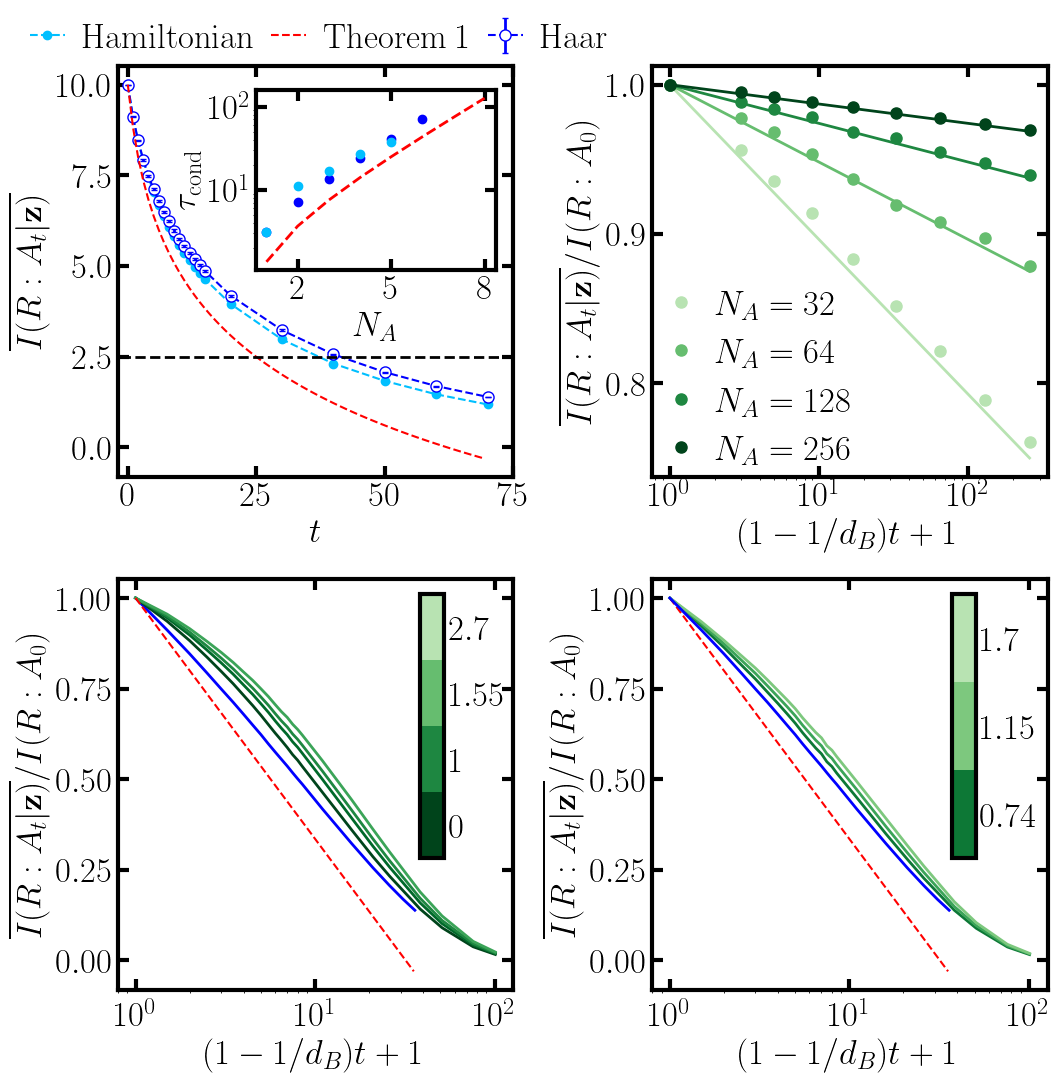

In [70]:
Na = 5
Nb = 1

avgMI = np.load(f'data/seqModel/Na{Na}/monitored/avgMI_Na{Na}Nb{Nb}.npz')
avgMI_ext = 2*np.load(f'data/seqModel/Na{Na}/monitored/bell/vnEntropy_Na{Na}Nb{Nb}_mc.npy').mean(2)
avgMI_h = np.load(f'data/seqModel/Na{Na}/sameU/avgMIIsing_Na{Na}Nb{Nb}.npz')

deltas = [0, 1, 1.55, 2.7]
path = f'data/seqModel/Na{Na}/monitored/nonBell/'
avgMI_delta = []
for delta in deltas:
    each = np.load(os.path.join(path, f'delta{delta}/avgMI_Na{Na}Nb{Nb}_del{delta}.npz'))
    avgMI_delta.append(each)

deltas_cq = [0.74, 1.15, 1.7]
path = f'data/seqModel/Na{Na}/monitored/CQ/'
avgMI_cq = []
for delta in deltas_cq:
    each = np.load(os.path.join(path, f'delta{delta}/avgMI_Na{Na}Nb{Nb}_del{delta}.npz'))
    avgMI_cq.append(each)

Nas = 2**np.arange(5, 9) 
Ts1 = np.array([0]+[2**i for i in range(1, 9)])
I_cond = np.zeros((len(Nas), len(Ts1), 50))
for k in range(len(Nas)):
    path = f'data/seqModel/clifford/Na{Nas[k]}/monitored/'

    I_cond[k, 0] = 2*Nas[k]
    for i in range(1, len(Ts1)):
        EE = np.load(os.path.join(path, f'EEhalf_Na{Nas[k]}Nb{16}T{Ts1[i]}.npy'))
        I_cond[k, i] = EE.mean(1) * 2.


fig, axs = plt.subplots(2, 2, figsize=(12, 12))
axs[0, 0].errorbar(avgMI['t'], avgMI['MI'].mean(1), yerr=avgMI['MI'].std(1), fmt='o--', mfc='white', barsabove=True,
                markersize=8, capsize=2, elinewidth=2, c='b', label=r'$\rm Haar$')
axs[0, 0].plot(avgMI_h['t'], avgMI_h['MI'], 'o--', markersize=6, c='deepskyblue', label=r'$\rm Hamiltonian$', zorder=1)
axs[0, 0].plot(2*Na - 2*np.log2((1 - 1/2**Nb)*np.arange(70) + 1), '--', c='r', label=r'$\rm Theorem\:1$')
axs[0, 0].hlines(0.25*2*Na, xmin=-10, xmax=80, ls='--', color='k', lw=2)
axs[0, 0].set_xlim(-2, 72)
axs[0, 0].set_xticks([0, 25, 50, 75])
axs[0, 0].set_xlabel(r'$t$')
axs[0, 0].legend(ncol=3, loc='upper left', bbox_to_anchor=(-0.3, 1.18), handlelength=1,
    framealpha=0, handletextpad=0.5, columnspacing=0.5)
axs[0, 0].set_ylabel(r'$\overline{I(R:A_t|\mathbf{z})}$')

inset = fig.add_axes([0.24, 0.71, 0.2, 0.15])

Tc = [3.1, 7.1, 13.5, 24, 41, 70] # epsilon = 0.25
Tc_h = [3.1, 11, 16.9, 27, 38]
inset.plot(np.arange(1, len(Tc)+1), Tc, 'o', markersize=6, c='b')
inset.plot(np.arange(1, len(Tc_h)+1), Tc_h, 'o', markersize=6, c='deepskyblue')
inset.plot(np.arange(1, 9), 2**Nb*(2.**((1-0.25)*np.arange(1, 9)) - 1)/(2**Nb-1), 
    '--', lw=2, c='r', label='theory')
inset.set_yscale('log')
inset.set_xticks([2, 5, 8])
inset.set_ylabel(r'$\tau_{\rm cond}$')
inset.set_xlabel(r'$N_A$')
inset.tick_params(direction='in', top='on', right='on', length=8, width=3)

greens1 = plt.cm.Greens(np.linspace(0.3, 1, len(Nas)))
for k in range(len(Nas)):
    axs[0, 1].plot((1.-1./2.**16)*Ts1+1., I_cond[k].mean(1)/(2*Nas[k]), 'o', c=greens1[k], 
                markersize=8, label=fr'$N_A={Nas[k]}$')
    axs[0, 1].plot((1.-1./2.**16)*np.arange(257)+1., 1. - np.log2((1. - 1./2.**16)*np.arange(257) + 1.)/Nas[k], 
                lw=2, c=greens1[k])
axs[0, 1].set_xscale('log')
axs[0, 1].set_xlabel(r'$(1-1/d_B)t+1$')
axs[0, 1].set_ylabel(r'$\overline{I(R:A_t|\mathbf{z})}/I(R:A_0)$')
axs[0, 1].legend(handlelength=1, framealpha=0, handletextpad=0.5, loc='lower left', bbox_to_anchor=(-0.05, -0.05))


axs[1, 0].plot(0.5*avgMI['t']+1, avgMI['MI'].mean(1)/(2*Na), lw=2, c='b')
greens1 = plt.cm.Greens(np.linspace(0.3, 1, 7))[::-1]
for i in range(len(deltas)):
    axs[1, 0].plot(0.5*avgMI_delta[i]['t']+1, avgMI_delta[i]['MI'].mean(1)/avgMI_delta[i]['MI'][0, 0], lw=2, c=greens1[i])
z = 0.5*np.arange(70)+1
axs[1, 0].plot(z, 1 - np.log2(z)/Na, '--', c='r', label=r'$\rm Theorem\:1$')
axs[1, 0].set_xlabel(r'$(1-1/d_B)t+1$')
axs[1, 0].set_ylabel(r'$\overline{I(R:A_t|\mathbf{z})}/I(R:A_0)$')

pos = axs[1, 0].get_position()
cax1 = fig.add_axes([pos.x0 + pos.width-0.1, pos.y0+0.11, 0.02, pos.height-0.13])
cmap = ListedColormap(greens1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=3))
cbar1 = plt.colorbar(sm, cax=cax1, orientation='vertical', boundaries=np.arange(5)-0.5)
cbar1.set_ticks(np.arange(4))
cbar1.set_ticklabels([fr'${deltas[i]}$' for i in range(4)])
cbar1.ax.tick_params(length=0)

offset_cq = [14, 22, 34, 52]
axs[1, 1].plot(0.5*np.hstack(avgMI['t'])+1, avgMI['MI'].mean(1)/(2*Na), lw=2, c='b', zorder=4)
greens2 = plt.cm.Greens(np.linspace(0.3, 1, 5))[:-1][::-1]
for i in range(len(deltas_cq)):
    axs[1, 1].plot(0.5*avgMI_cq[i]['t']+1, avgMI_cq[i]['MI'].mean(1)/avgMI_cq[i]['MI'][0,0], lw=2, c=greens2[i])
z = 0.5*np.arange(70)+1
axs[1, 1].plot(z, 1 - np.log2(z)/Na, '--', c='r', label=r'$\rm Theorem\:1$')
axs[1, 1].set_xlabel(r'$(1-1/d_B)t+1$')
axs[1, 1].set_ylabel(r'$\overline{I(R:A_t|\mathbf{z})}/I(R:A_0)$')

pos = axs[1, 1].get_position()
cax2 = fig.add_axes([pos.x0 + pos.width-0.08, pos.y0+0.11, 0.02, pos.height-0.13])
cmap = ListedColormap(greens2)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=2))
cbar2 = plt.colorbar(sm, cax=cax2, orientation='vertical', boundaries=np.arange(4)-0.5)
cbar2.set_ticks(np.arange(3))
cbar2.set_ticklabels([fr'${deltas_cq[i]}$' for i in range(3)])
cbar2.ax.tick_params(length=0)

for i in [0, 2, 3]:
    axs[i//2, i%2].set_yticks(np.arange(5)*2.5/10**(i//2))

for i in range(4):
    axs[i//2, i%2].tick_params(direction='in', top='on', right='on', length=8, width=3)
plt.subplots_adjust(wspace=0.35, hspace=0.25)

for i in range(2):
    axs[1, i].set_xscale('log')
    axs[1, i].tick_params(axis='x', pad=8)

plt.savefig('figures/condQMI.svg', bbox_inches='tight')
plt.show()
plt.close()

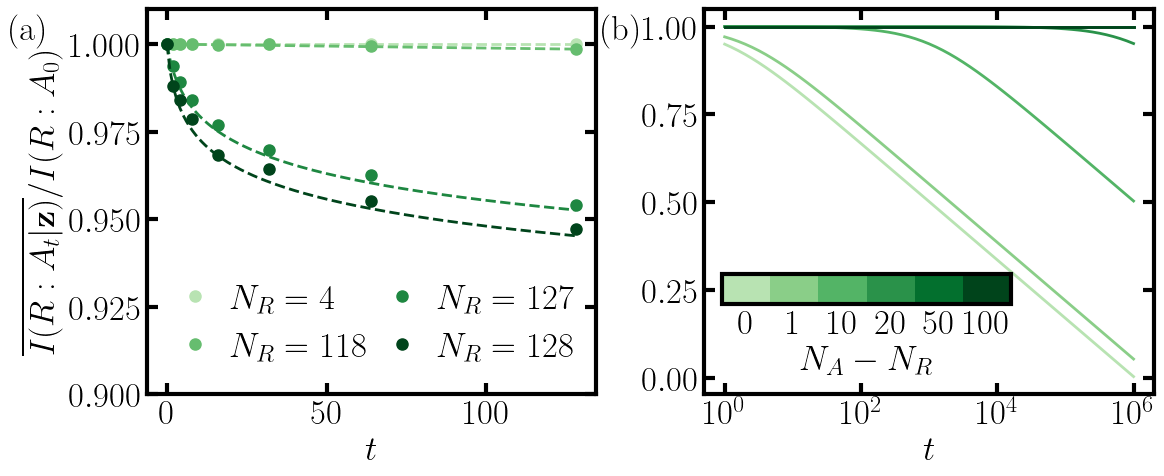

In [141]:
Nrs1 = [4, 118, 127, 128]
Na = 128
Nb = 16

path = f'data/seqModel/clifford/Na{Na}/monitored/'
Ts1 = np.array([0]+[2**i for i in range(1, 8)])
I_cond = np.zeros((len(Nrs1), len(Ts1), 50))
for i in range(len(Nrs1)-1):
    I_cond[i, 0] = 2*Nrs1[i]
    EE = np.load(os.path.join(path, f'EEhalf_Nr{Nrs1[i]}Na{Na}Nb{Nb}.npy'))
    I_cond[i, 1:] = 2*EE.mean(2)
I_cond[-1, 0] = 2*Nrs1[-1]
I_cond[-1, 1:] = 2*np.load(os.path.join(path, f'EEhalf_Na{Na}Nb{Nb}.npy'))[:-1].mean(2)

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
greens1 = plt.cm.Greens(np.linspace(0.3, 1, len(Nrs1)))
for i in range(len(Nrs1)):
    axs[0].plot(Ts1, I_cond[i].mean(1)/(2*Nrs1[i]), 'o', c=greens1[i], markersize=8, 
                label=fr'$N_R = {Nrs1[i]}$')
    ts = np.arange(129)
    c = 1. - (2.**(Nrs1[i])+1.)/(2.**(Nrs1[i]+Nb)) + 0.5/2.**Nrs1[i]
    axs[0].plot(ts, 1.-np.log2(1.+2.**(Nrs1[i]-Na)*ts*c)/Nrs1[i], '--', c=greens1[i], 
                lw=2)
axs[0].set_ylim(0.9, 1.01)
axs[0].set_xlabel(r'$t$')
axs[0].set_ylabel(r'$\overline{I(R:A_t|\mathbf{z})}/I(R:A_0)$')
axs[0].legend(handlelength=1, handletextpad=0.5, ncol=2, columnspacing=0.5, framealpha=0)

r_exponents = [0, 1, 10, 20, 50, 100]
greens1 = plt.cm.Greens(np.linspace(0.3, 1, len(r_exponents)))
ts = 10.**np.arange(0, 6.1, 0.1)
for i in range(len(r_exponents)):
    axs[1].plot(ts, 1. - np.log2(1. + 2.**(-r_exponents[i]) * ts)/20, lw=2, c=greens1[i])
axs[1].set_xscale('log')
axs[1].set_xlabel(r'$t$')
axs[1].set_xticks(10.**np.arange(0, 8, 2))

pos = axs[1].get_position()
cax2 = fig.add_axes([pos.x0+0.02, pos.y0+0.18, pos.width-0.13, 0.06])
cmap = ListedColormap(greens1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=6))
cbar2 = plt.colorbar(sm, cax=cax2, orientation='horizontal', boundaries=np.arange(7)-0.5)
cbar2.set_ticks(np.arange(6))
cbar2.set_ticklabels([fr'${r_exponents[i]}$' for i in range(6)])
cbar2.ax.tick_params(length=0)
cbar2.set_label(r'$N_A-N_R$')

for i in range(2):
    axs[i].tick_params(direction='in', top='on', right='on', length=8, width=3)

fig.text(0.02, 0.82, r'$\rm (a)$')
fig.text(0.475, 0.82, r'$\rm (b)$')

plt.subplots_adjust(wspace=0.24)

plt.savefig('figures/condQMI_lessR.pdf', bbox_inches='tight')
plt.show()
plt.close()

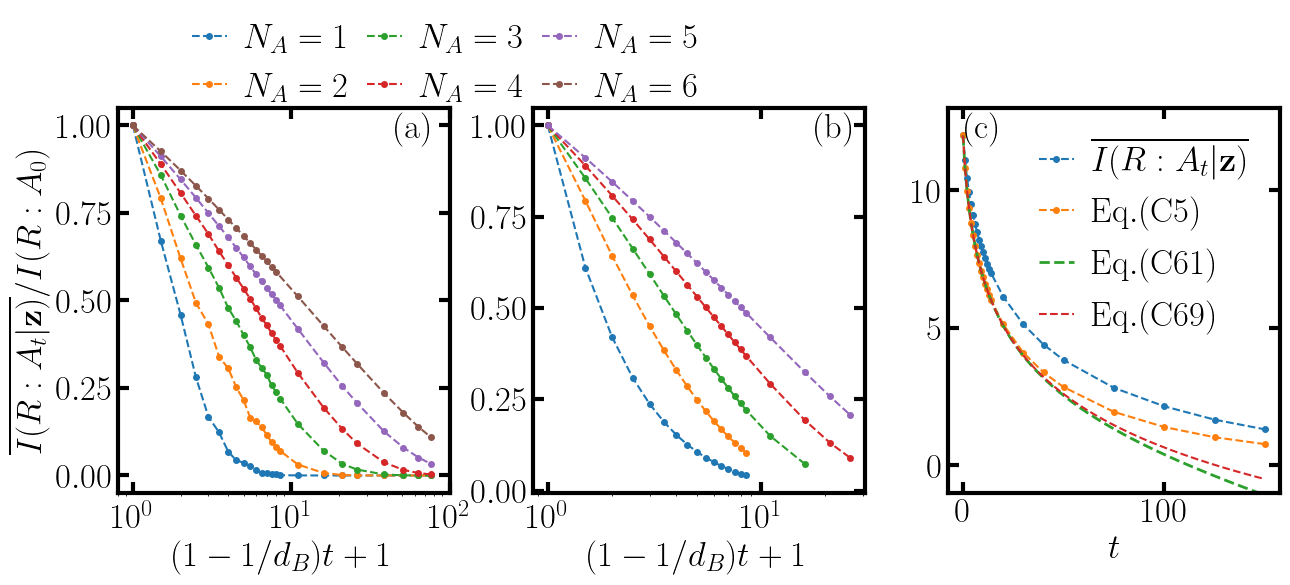

In [510]:
Na = np.arange(1, 7)
Nb = 1

avgMI = []
for i in range(len(Na)):
    each = np.load(f'data/seqModel/Na{Na[i]}/monitored/bell/avgMI_Na{Na[i]}Nb{Nb}.npz')
    avgMI.append(each)

lb = [1/2**Na[i]]
probs = np.load(f'data/seqModel/Na{Na[i]}/monitored/bell/probs_Na{Na[i]}Nb{Nb}_ex.npz')
purity = np.load(f'data/seqModel/Na{Na[i]}/monitored/bell/purity_Na{Na[i]}Nb{Nb}_ex.npz')
for k in range(14):
    lb.append((probs[f'arr_{k}'] * purity[f'arr_{k}']).sum(1).mean(0))
purity = np.load(f'data/seqModel/Na{Na[i]}/monitored/bell/purity_Na{Na[i]}Nb{Nb}_mc.npy')
lb.extend(purity.mean((1, 2)))

avgMI_same = []
for i in range(2):
    each = np.load(f'data/seqModel/Na{Na[i]}/sameU/avgS1_Na{Na[i]}Nb{Nb}_ex.npy')
    avgMI_same.append(2*each)
for i in range(2, len(Na)-1):
    each = np.load(f'data/seqModel/Na{Na[i]}/sameU/avgMI_Na{Na[i]}Nb{Nb}.npz')
    avgMI_same.append(each)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i in range(len(Na)):
    axs[0].plot(0.5*avgMI[i]['t']+1, avgMI[i]['MI'].mean(1)/(2*Na[i]), 'o--', markersize=4,
                label=fr'$N_A={Na[i]}$')
axs[0].legend(handlelength=1, handletextpad=0.5, ncol=3, columnspacing=0.5, loc='upper left',
              bbox_to_anchor=(0.13, 1.3), framealpha=0)
axs[0].set_ylabel(r'$\overline{I(R:A_t|\mathbf{z})}/I(R:A_0)$')
axs[0].set_xlabel(r'$(1-1/d_B)t+1$')
axs[0].set_xlim(0.8, 100)

for i in range(2):
    axs[1].plot(0.5*np.arange(len(avgMI_same[i]))+1, avgMI_same[i].mean(1)/(2*Na[i]), 'o--', markersize=4, label=fr'$N_A={Na[i]}$')
for i in range(2, len(Na)-1):
    axs[1].plot(0.5*avgMI_same[i]['t']+1, avgMI_same[i]['MI'].mean(1)/(2*Na[i]), 'o--', markersize=4,
                label=fr'$N_A={Na[i]}$')
axs[1].set_xlabel(r'$(1-1/d_B)t+1$')

axs[2].plot(avgMI[-1]['t'], avgMI[-1]['MI'].mean(1), 'o--', markersize=4, label=r'$\overline{I(R:A_t|\mathbf{z})}$')
axs[2].plot(avgMI[-1]['t'], -2*np.log2(lb), 'o--', markersize=4, label=r'$\rm Eq.(C5)$')
axs[2].plot(avgS2(Na[-1], Nb, np.arange(151))*2, '--', lw=2, label=r'$\rm Eq.(C61)$')
axs[2].plot(2*Na[-1] - np.log2((1-1/2**Nb)*np.arange(151) + 1)*2, '--', label=r'$\rm Eq.(C69)$')

axs[2].legend(handlelength=1, handletextpad=0.5, framealpha=0)
axs[2].set_xlabel(r'$t$')
axs[2].set_ylim(-1, 13)

for i in range(2):
    axs[i].set_xscale('log')
    axs[i].tick_params(axis='x', pad=8)
    
for i in range(3):
    axs[i].tick_params(direction='in', top='on', right='on', length=8, width=3)

plt.subplots_adjust(wspace=0.25)

fig.text(0.31, 0.82, r'$\rm (a)$')
fig.text(0.59, 0.82, r'$\rm (b)$')
fig.text(0.69, 0.82, r'$\rm (c)$')

plt.savefig('figures/condQMI_haar_detail.pdf', bbox_inches='tight')
plt.show()
plt.close()

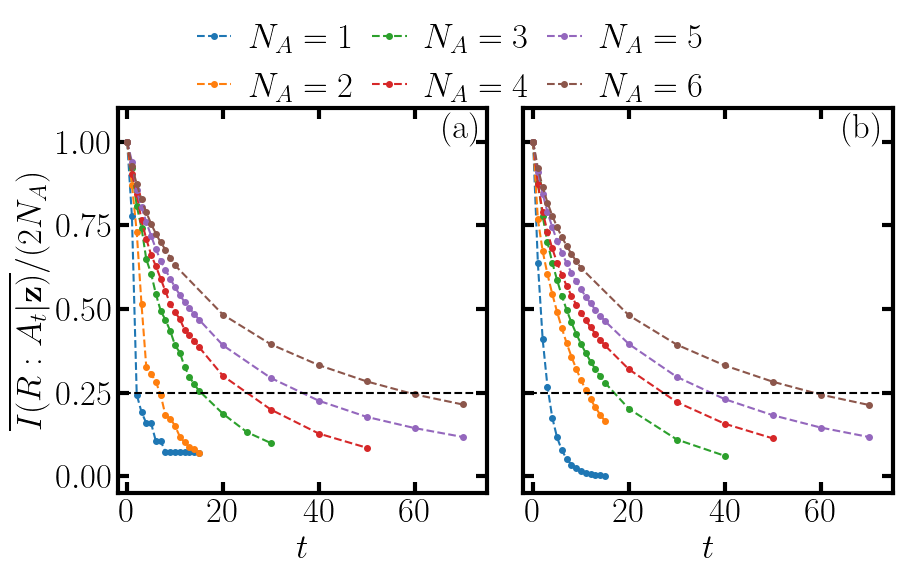

In [ ]:
Na = np.arange(1, 7)
Nb = 1

avgMI = []
for i in range(2):
    each = np.load(f'data/seqModel/Na{Na[i]}/avgS1Ising_Na{Na[i]}Nb{Nb}.npy')
    avgMI.append(2*each)
for i in range(2, len(Na)):
    each = np.load(f'data/seqModel/Na{Na[i]}/MIIsing_Na{Na[i]}Nb{Nb}.npz')
    avgMI.append(each)

avgMI_same = []
for i in range(len(Na)):
    each = np.load(f'data/seqModel/Na{Na[i]}/sameU/avgMIIsing_Na{Na[i]}Nb{Nb}.npz')
    avgMI_same.append(each)

fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

for i in range(2):
    axs[0].plot(avgMI[i]/(2*Na[i]), 'o--', markersize=4, label=fr'$N_A={Na[i]}$')
for i in range(2, len(Na)):
    axs[0].plot(avgMI[i]['t'], avgMI[i]['MI']/(2*Na[i]), 'o--', markersize=4,
                label=fr'$N_A={Na[i]}$')
axs[0].hlines(0.25, xmin=-10, xmax=80, ls='--', color='k')
axs[0].legend(handlelength=1, handletextpad=0.5, ncol=3, columnspacing=0.5, loc='upper left',
              bbox_to_anchor=(0.13, 1.3), framealpha=0)
axs[0].set_ylabel(r'$\overline{I(R:A_t|\mathbf{z})}/(2N_A)$')
axs[0].set_xlabel(r'$t$')
axs[0].set_xlim(-2, 75)
axs[0].set_ylim(-0.05, 1.1)

for i in range(len(Na)):
    axs[1].plot(avgMI_same[i]['t'], avgMI_same[i]['MI']/(2*Na[i]), 'o--', markersize=4, label=fr'$N_A={Na[i]}$')
axs[1].hlines(0.25, xmin=-10, xmax=80, ls='--', color='k')
axs[1].set_xlabel(r'$t$')

for i in range(2):
    axs[i].set_xticks([0, 20, 40, 60])
    axs[i].tick_params(direction='in', top='on', right='on', length=8, width=3)

plt.subplots_adjust(wspace=0.1)

fig.text(0.45, 0.82, r'$\rm (a)$')
fig.text(0.85, 0.82, r'$\rm (b)$')

#plt.savefig('figures/condQMI_ising_detail.pdf', bbox_inches='tight')
plt.show()
plt.close()

## super-late dynamics of measurement unconditioned QMI

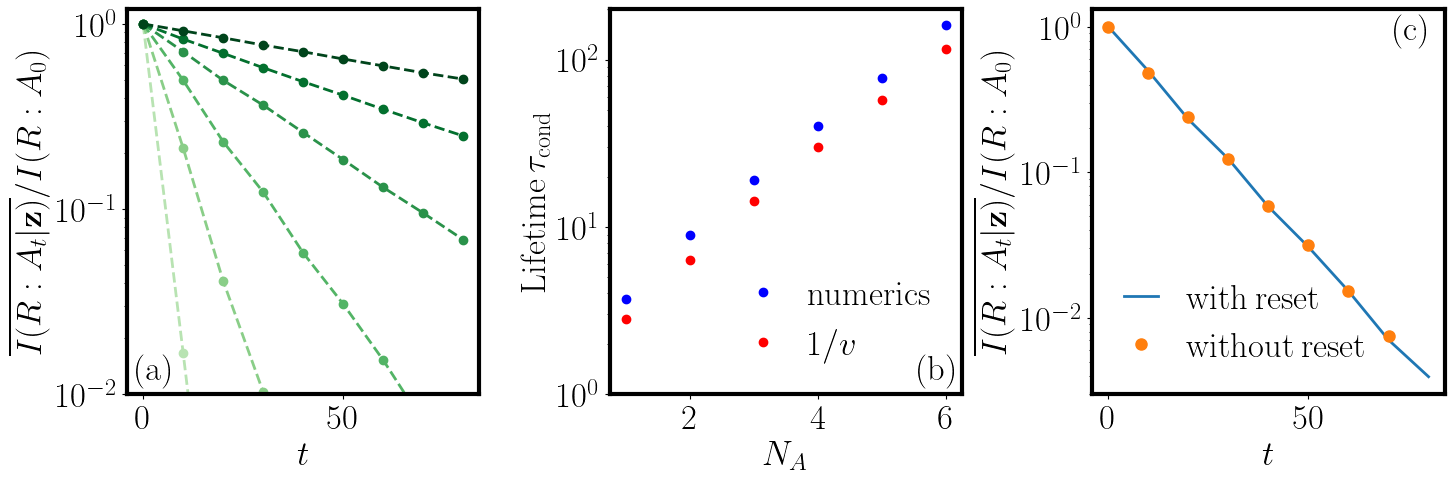

In [225]:
Na = np.arange(1, 7)
Nb = 1

avgMI = []
for i in range(len(Na)):
    each = np.load(f'data/seqModel/Na{Na[i]}/monitored/bellLate/vnEntropy_Na{Na[i]}Nb{Nb}_mc.npy')
    avgMI.append(2*each.mean(2))

avgMI_noReset = 2*np.load('data/seqModel/Na3/noReset/data/vnEntropyLate_Na3Nb1_mc.npy').mean(2)

fig, axs = plt.subplots(1, 3, figsize=(17, 5))
ps = []

greens = plt.cm.Greens(np.linspace(0.3, 1, 6))
for i in range(len(Na)):
    axs[0].plot(np.arange(len(avgMI[i]))*10, avgMI[i].mean(1)/avgMI[i][0,0], 'o--', markersize=6,
            c=greens[i], lw=2, label=fr'$N_A={Na[i]}$')
    p = np.polyfit(np.arange(len(avgMI[i]))*10, y=np.log(avgMI[i].mean(1)/avgMI[i][0,0]), deg=1)
    ps.append(p[0])
#axs[0].plot(np.exp(p[0]*np.arange(200)+p[1]), '--', c='k')
# axs[0].legend(loc='upper left', bbox_to_anchor=(-0.38, 1.3), ncol=3, handlelength=1,
#     framealpha=0, handletextpad=0.5, columnspacing=1)
# axs[0].hlines(0.25, 0, 200, 'k', '--')
# axs[0].vlines(160, 1e-2, 1, 'k', '--')
axs[0].set_yscale('log')
axs[0].set_ylim(1e-2, 1.2)
axs[0].set_ylabel(r'$\overline{I(R:A_t|\mathbf{z})}/I(R:A_0)$')
axs[0].set_xlabel(r'$t$')

tau = [3.7, 9, 19, 40, 78, 160]
axs[1].plot(Na, tau, 'o', markersize=6, c='b', label=r'$\rm numerics$')
axs[1].plot(Na, -1/np.array(ps), 'o', markersize=6, c='r', label=r'$1/v$')
axs[1].legend(framealpha=0, handlelength=1)
axs[1].set_yscale('log')
axs[1].set_ylim(1, 200)
axs[1].set_xlabel(r'$N_A$')
axs[1].set_ylabel(r'${\rm Lifetime\:}\tau_{\rm cond}$')

axs[2].plot(np.arange(9)*10, avgMI[2].mean(1)/avgMI[2][0, 0], lw=2, label=r'$\rm with\: reset$')
axs[2].plot(np.arange(8)*10, avgMI_noReset.mean(1)/avgMI_noReset[0, 0], 'o', markersize=8, label=r'$\rm without\:reset$')
axs[2].legend(framealpha=0, handlelength=1, loc='lower left')
axs[2].set_ylabel(r'$\overline{I(R:A_t|\mathbf{z})}/I(R:A_0)$')
axs[2].set_xlabel(r'$t$')
axs[2].set_yscale('log')

plt.subplots_adjust(wspace=0.37)

fig.text(0.13, 0.14, r'$\rm (a)$')
fig.text(0.59, 0.14, r'$\rm (b)$')
fig.text(0.87, 0.82, r'$\rm (c)$')

plt.savefig('figures/condQMI_late.pdf', bbox_inches='tight')
plt.show()
plt.close()

## measurement-unconditioned QMI

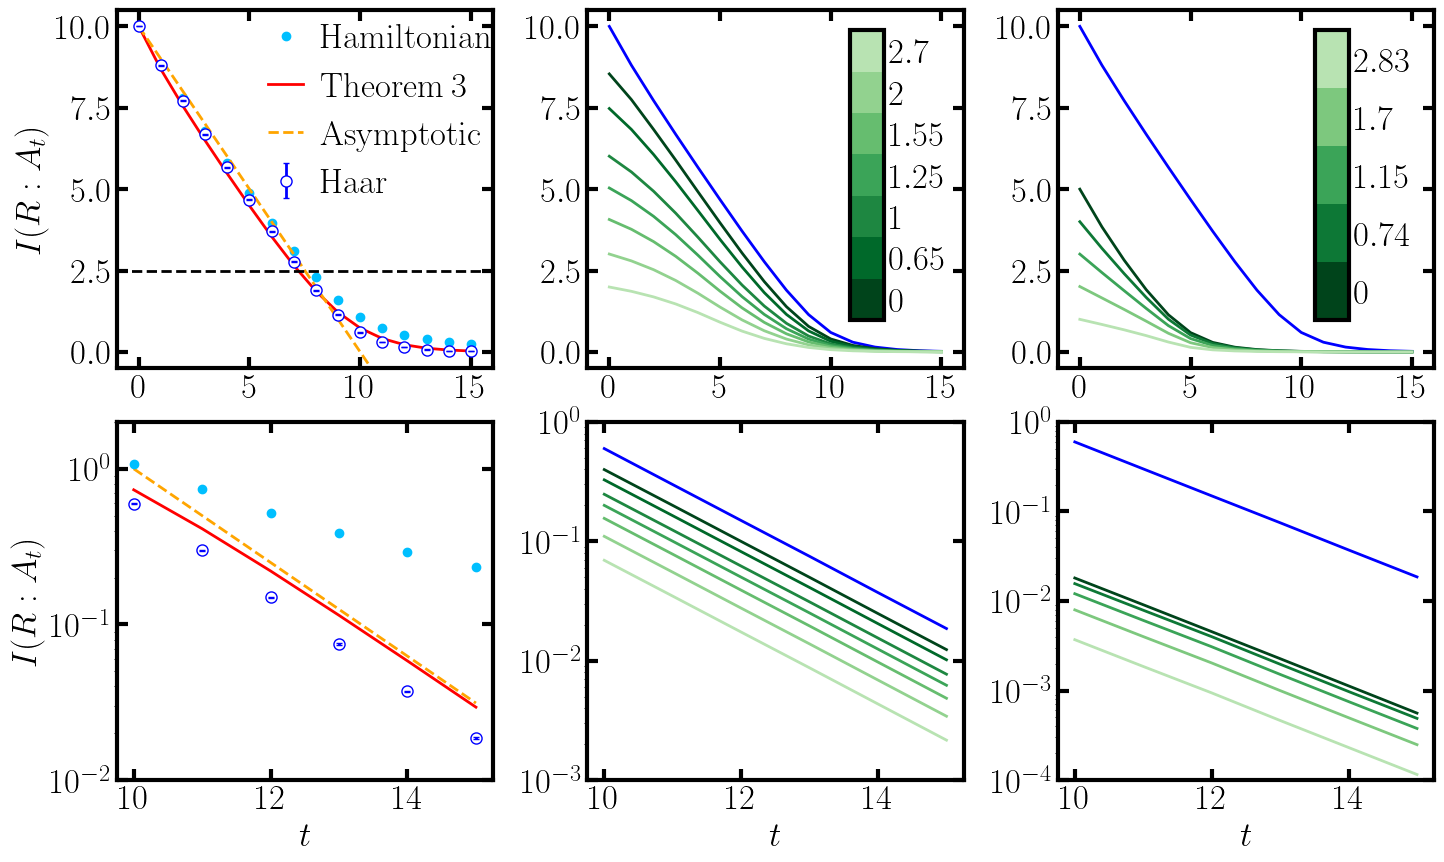

In [17]:
Na = 5
Nb = 1
path = f'data/seqModel/Na{Na}/traceout/'

MI = np.load(os.path.join(path, f'bell/MI_Na{Na}Nb{Nb}_traceout.npy'))
MI_h = np.load(f'data/seqModel/Na{Na}/sameU/MIIsing_Na{Na}Nb{Nb}_traceout.npy')

deltas = [0, 0.65, 1, 1.25, 1.55, 2, 2.7]
MI_delta = []
for delta in deltas:
    each = np.load(os.path.join(path, f'nonBell/delta{delta}/MI_Na{Na}Nb{Nb}_del{delta}_traceout.npy'))
    MI_delta.append(each.mean(1))

deltas_cq = [0, 0.74, 1.15, 1.7, 2.83]
MI_cq = []
for delta in deltas_cq:
    each = np.load(os.path.join(path, f'CQ/delta{delta}/MI_Na{Na}Nb{Nb}_del{delta}_traceout.npy'))
    MI_cq.append(each.mean(1))

fig, axs = plt.subplots(2, 3, figsize=(17, 10))
axs[0, 0].errorbar(np.arange(16), MI.mean(1), yerr=MI.std(1), fmt='o', mfc='white', barsabove=True, markersize=8, 
                capsize=2, elinewidth=2, c='b', label=r'$\rm Haar$')
axs[0, 0].plot(np.hstack((2*Na, MI_h)), 'o', markersize=6, c='deepskyblue', label=r'$\rm Hamiltonian$', zorder=1)
axs[0, 0].plot(MIR2_traceout(Na, Nb, np.arange(16)), lw=2, c='r', label=r'$\rm Theorem\:3$', zorder=1)
axs[0, 0].plot(2*Na - np.arange(15)*Nb, '--', lw=2, c='orange', label=r'$\rm Asymptotic$', zorder=1)
axs[0, 0].hlines(0.25*2*Na, xmin=-10, xmax=20, ls='--', color='k', lw=2)
axs[0, 0].legend(loc='upper left', bbox_to_anchor=(0.32, 1.05), handlelength=1,
    framealpha=0, handletextpad=0.5, columnspacing=1)

axs[1, 0].errorbar(np.arange(10, 16), MI.mean(1)[10:], yerr=MI.std(1)[10:], fmt='o', mfc='white', barsabove=True, 
                markersize=8, capsize=2, elinewidth=2, c='b')
axs[1, 0].plot(np.arange(10, 16), MI_h[9:], 'o', markersize=6, c='deepskyblue')
axs[1, 0].plot(np.arange(10, 16), MIR2_traceout(Na, Nb, np.arange(10, 16)), lw=2, c='r')
axs[1, 0].plot(np.arange(10, 16), 4**Na*2.**(-Nb*np.arange(10, 16)), '--', lw=2, c='orange', zorder=1)
axs[1, 0].set_yscale('log')
axs[1, 0].set_ylim(1e-2, 2)

offset_delta = [1.3, 2.3, 3.7, 4.7, 5.7, 6.8, 7.9]
axs[0, 1].plot(MI.mean(1), lw=2, c='b')
greens1 = plt.cm.Greens(np.linspace(0.3, 1, 7))[::-1]
for i in range(len(deltas)):
    axs[0, 1].plot(np.arange(16), MI_delta[i], lw=2, c=greens1[i])
pos = axs[0, 1].get_position()
cax1 = fig.add_axes([pos.x0+pos.width-0.07, pos.y0+0.04, 0.02, pos.height-0.06])
cmap = ListedColormap(greens1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=6))
cbar1 = plt.colorbar(sm, cax=cax1, orientation='vertical', boundaries=np.arange(8)-0.5)
cbar1.set_ticks(np.arange(7))
cbar1.set_ticklabels([fr'${deltas[i]}$' for i in range(7)])
cbar1.ax.tick_params(length=0)

axs[1, 1].plot(np.arange(10, 16), MI.mean(1)[10:], lw=2, c='b')
for i in range(len(deltas)):
    axs[1, 1].plot(np.arange(10, 16), MI_delta[i][10:], lw=2, c=greens1[i])
axs[1, 1].set_yscale('log')
axs[1, 1].set_ylim(1e-3, 1)

offset_cq = [4.7, 5.7, 6.8, 7.9, 9.3]
axs[0, 2].plot(MI.mean(1), lw=2, c='b')
greens2 = plt.cm.Greens(np.linspace(0.3, 1, 5))[::-1]
for i in range(len(deltas_cq)):
    axs[0, 2].plot(np.arange(16), MI_cq[i], lw=2, c=greens2[i])
pos = axs[0, 2].get_position()
cax2 = fig.add_axes([pos.x0+pos.width-0.07, pos.y0+0.04, 0.02, pos.height-0.06])
cmap = ListedColormap(greens2)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=4))
cbar2 = plt.colorbar(sm, cax=cax2, orientation='vertical', boundaries=np.arange(6)-0.5)
cbar2.set_ticks(np.arange(5))
cbar2.set_ticklabels([fr'${deltas_cq[i]}$' for i in range(5)])
cbar2.ax.tick_params(length=0)


axs[1, 2].plot(np.arange(10, 16), MI.mean(1)[10:], lw=2, c='b')
for i in range(len(deltas_cq)):
    axs[1, 2].plot(np.arange(10, 16), MI_cq[i][10:], lw=2, c=greens2[i])
axs[1, 2].set_yscale('log')
axs[1, 2].set_ylim(1e-4, 1)

for i in range(3):
    axs[0, i].set_ylim(-0.5, 10.5)
    axs[0, i].set_xlim(-1, 16)
    axs[0, i].set_xticks(np.arange(4)*5)
    axs[1, i].set_xlabel(r'$t$')
    axs[0, i].tick_params(direction='in', top='on', right='on', length=8, width=3)
    axs[1, i].tick_params(direction='in', top='on', right='on', length=8, width=3)

axs[0, 0].set_ylabel(r'$I(R:A_t)$')
axs[1, 0].set_ylabel(r'$I(R:A_t)$')

plt.subplots_adjust(wspace=0.25, hspace=0.15)

plt.savefig('figures/uncondQMI_dynamics.svg', bbox_inches='tight')
plt.show()
plt.close()

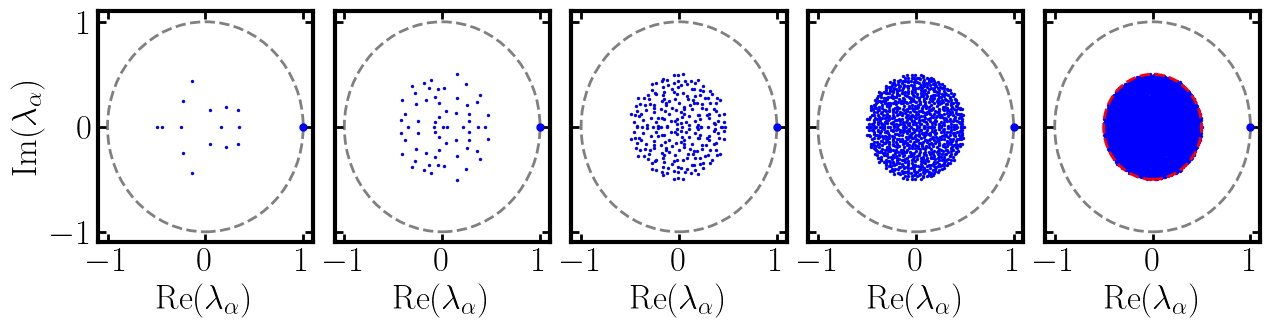

In [5]:
vals = np.load(f'data/mem_Volterra/channelVal_haar_Nb2.npz')
vals = [vals[f'arr_{i}'] for i in range(6)]

fig, axs = plt.subplots(1, 5, figsize=(15, 3), sharey=True, sharex=True)
for i in range(5):
    axs[i].scatter(np.real(vals[i+1]), np.imag(vals[i+1]), s=2, c='b')
    circ = plt.Circle((0, 0), radius=1, edgecolor='gray', facecolor='None', lw=2, ls='--')
    axs[i].add_patch(circ)
    axs[i].plot(1, 0, 'o', c='b', markersize=5)

    axs[i].set_xlabel(r'${\rm Re}(\lambda_\alpha)$')
    axs[i].tick_params(direction='in', top='on', right='on', length=6, width=2)
circ = plt.Circle((0, 0), radius=1/np.sqrt(2**2), edgecolor='r', facecolor='None', lw=2, ls='--')
axs[-1].add_patch(circ)
axs[0].set_ylabel(r'${\rm Im}(\lambda_\alpha)$')
plt.subplots_adjust(wspace=0.1)

plt.savefig('figures/spectrum_haar.svg', bbox_inches='tight')
plt.show()
plt.close()

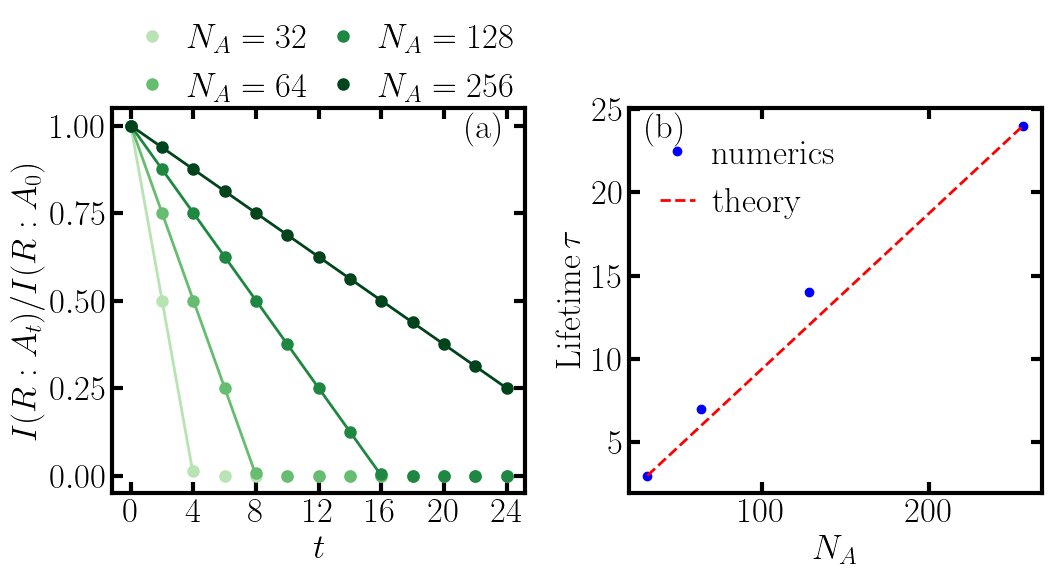

In [45]:
Nas = [32, 64, 128, 256]
Nb = 16
Ts2 = np.arange(0, 25, 2)
I_uncond = np.zeros((len(Nas), len(Ts2), 50))
for k in range(len(Nas)):
    path = f'data/seqModel/clifford/Na{Nas[k]}/traceout/'
    I_uncond[k] = np.load(os.path.join(path, f'MI_Na{Nas[k]}Nb{Nb}.npy'))

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
greens1 = plt.cm.Greens(np.linspace(0.3, 1, len(Nas)))
for k in range(len(Nas)):
    axs[0].plot(Ts2, I_uncond[k].mean(1)/(2*Nas[k]), 'o', markersize=8, c=greens1[k], label=fr'$N_A={Nas[k]}$')
    axs[0].plot(np.arange(min(2*Nas[k]//Nb+1, 25)), 1. - np.arange(min(2*Nas[k]//Nb+1, 25))*Nb/(2*Nas[k]), lw=2, c=greens1[k])
axs[0].set_xlabel(r'$t$')
axs[0].set_ylabel(r'$I(R:A_t)/I(R:A_0)$')
axs[0].set_xticks(np.arange(7)*4)
axs[0].legend(handlelength=1, handletextpad=0.5, ncol=2, columnspacing=0.5, framealpha=0,
              loc='upper left', bbox_to_anchor=(-0.02, 1.3))

axs[1].plot(Nas, [3, 7, 14, 24], 'o', markersize=6, c='b', label=r'$\rm numerics$')
axs[1].plot(np.arange(32, 257), 2*(1-0.25)*np.arange(32, 257)/Nb, '--', c='r', lw=2, label=r'$\rm theory$')
axs[1].set_xlabel(r'$N_A$')
axs[1].set_ylabel(r'${\rm Lifetime}\:\tau$')
axs[1].legend(handlelength=1, handletextpad=0.5, framealpha=0)

for i in range(2):
    axs[i].tick_params(direction='in', top='on', right='on', length=8, width=3)

fig.text(0.42, 0.82, r'$\rm (a)$')
fig.text(0.57, 0.82, r'$\rm (b)$')

plt.subplots_adjust(wspace=0.25)

plt.savefig('figures/uncondQMI_clifford.pdf', bbox_inches='tight')
plt.show()
plt.close()

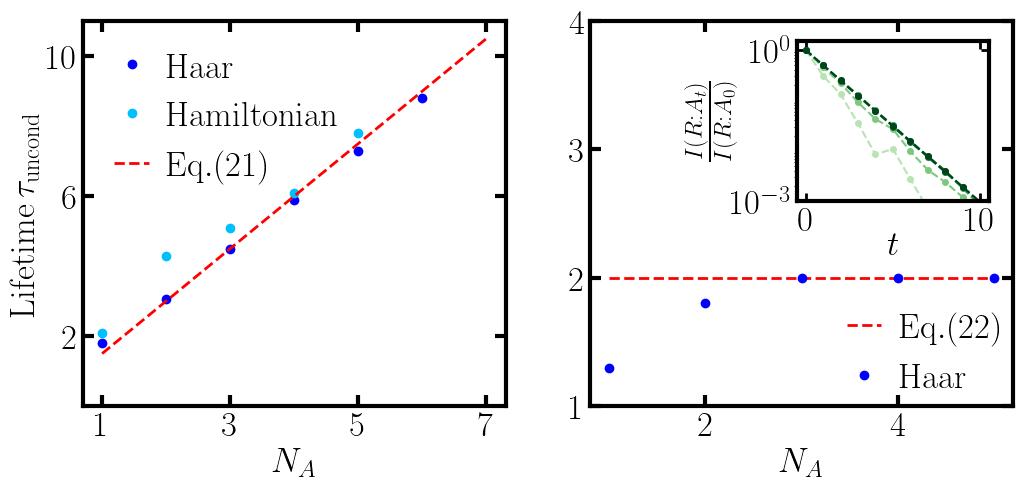

In [48]:
Nb = 1
MI = []
for i in range(5):
    each = np.load(f'data/seqModel/Na{i+1}/traceout/bellLate/MI_Na{i+1}Nb1_traceout.npy')
    MI.append(each)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
Tc = [1.8, 3.05, 4.5, 5.9, 7.3, 8.8] # epsilon = 0.25
Tc_h = [2.1, 4.3, 5.1, 6.1, 7.8]
axs[0].plot(np.arange(1, len(Tc)+1), Tc, 'o',  markersize=6, c='b', label=r'$\rm Haar$')
axs[0].plot(np.arange(1, len(Tc_h)+1), Tc_h, 'o',  markersize=6, c='deepskyblue', label=r'$\rm Hamiltonian$')
axs[0].plot(np.arange(1, 8), 2*(1-0.25)*np.arange(1, 8)/Nb, '--', lw=2, c='r', label=r'$\rm Eq. (21)$')
axs[0].legend(handlelength=1, framealpha=0, handletextpad=0.5, loc='upper left')
axs[0].set_ylim(0, 11)
axs[0].set_yticks([2, 6, 10])
axs[0].set_xticks([1, 3, 5, 7])
axs[0].set_ylabel(r'${\rm Lifetime\:}\tau_{\rm uncond}$')
axs[0].set_xlabel(r'$N_A$')

Tc = [1.3, 1.8, 2, 2, 2]
axs[1].plot(np.arange(1, len(Tc)+1), np.log2(1/0.25)/Nb*np.ones_like(Tc), '--', lw=2, c='r', label=r'$\rm Eq.(22)$')
axs[1].plot(np.arange(1, len(Tc)+1), Tc, 'o',  markersize=6, c='b', label=r'$\rm Haar$')
axs[1].set_xlabel(r'$N_A$')
axs[1].set_ylim(1, 4)
axs[1].legend(handlelength=1, framealpha=0, handletextpad=0.5, loc='lower right', bbox_to_anchor=(1.05, -0.05))

h = 0.32
inset = fig.add_axes([0.72, 0.52, h/2, h])
greens = plt.cm.Greens(np.linspace(0.3, 1, 5))
for i in range(5):
    inset.plot(MI[i].mean(1)[:11]/MI[i][0, 0], 'o--', markersize=4, c=greens[i])
inset.set_yscale('log')
inset.set_ylim(1e-3, 1.5)
inset.set_yticks([1e-3, 1])
inset.set_xlabel(r'$t$', labelpad=-5)
inset.set_ylabel(r'$\frac{I(R:A_t)}{I(R:A_0)}$', labelpad=-5)

inset.tick_params(direction='in', top='on', right='on', length=6, width=2)
for i in range(2):
    axs[i].tick_params(direction='in', top='on', right='on', length=8, width=3)

plt.savefig('figures/uncondQMI_lifetime.svg', bbox_inches='tight')
plt.show()
plt.close()

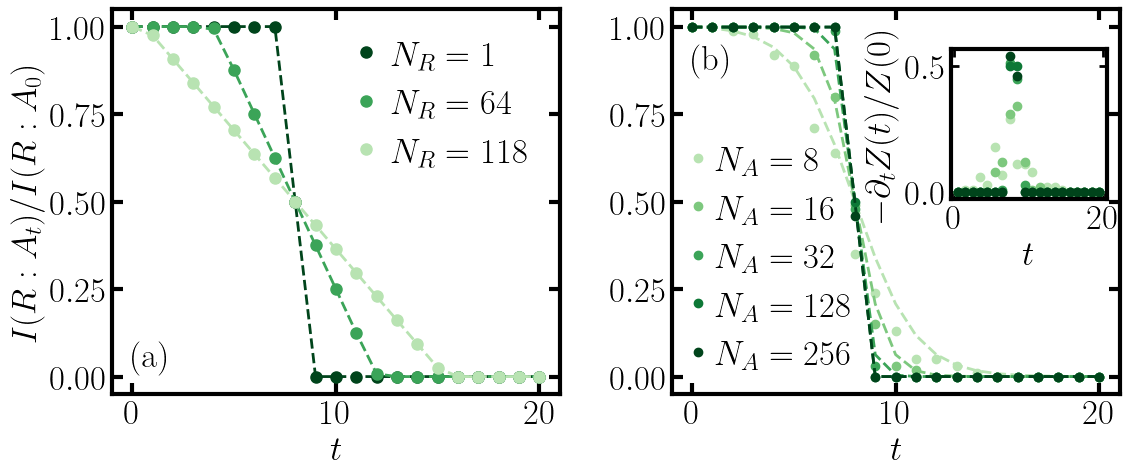

In [2]:
Nrs1 = [1, 64, 118]
Na = 128
Nb = 16
path = f'data/seqModel/clifford/Na{Na}/traceout/'
Ts = np.arange(21)
I_uncond1 = np.zeros((len(Nrs1), len(Ts), 50))
for i in range(len(Nrs1)):
    I_uncond1[i] = np.load(os.path.join(path, f'MI_Nr{Nrs1[i]}Na{Na}Nb{Nb}.npy'))

Nr = 1
Nas = [8, 16, 32, 128, 256]
I_uncond2 = np.zeros((len(Nas), len(Ts), 50))
for i in range(len(Nas)):
    path = f'data/seqModel/clifford/Na{Nas[i]}/traceout/'
    I_uncond2[i] = np.load(os.path.join(path, f'MI_Nr{Nr}Na{Nas[i]}Nb{Nas[i]//8}.npy'))

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
greens1 = plt.cm.Greens(np.linspace(0.3, 1, len(Nrs1)))[::-1]
for i in range(len(Nrs1)):
    axs[0].plot(Ts, I_uncond1[i].mean(1)/(2*Nrs1[i]), 'o', c=greens1[i], markersize=8, 
                label=fr'$N_R = {Nrs1[i]}$')
    I2 = np.log2(1. + 2.**(Nrs1[i]+Na-Nb*Ts)) - np.log2(1.+(2.**(Na-Nrs1[i])-1.)*2.**(-Nb*Ts))
    axs[0].plot(Ts, I2/(2*Nrs1[i]), '--', c=greens1[i], lw=2)
axs[0].set_xlabel(r'$t$')
axs[0].set_ylabel(r'$I(R:A_t)/I(R:A_0)$')
axs[0].legend(handlelength=1, handletextpad=0.2, framealpha=0)

greens2 = plt.cm.Greens(np.linspace(0.3, 1, len(Nas)))
for i in range(len(Nas)):
    axs[1].plot(Ts, I_uncond2[i].mean(1)/(2*Nr), 'o', c=greens2[i], label=fr'$N_A={Nas[i]}$')
    I2 = np.log2(1. + 2.**(Nr+Nas[i]-(Nas[i]//8)*Ts)) - np.log2(1.+(2.**(Nas[i]-Nr)-1.)*2.**(-Nas[i]//8*Ts))
    axs[1].plot(Ts, I2/(2*Nr), '--', c=greens2[i], lw=2)
axs[1].set_xlabel(r'$t$')
axs[1].legend(handlelength=1, handletextpad=0., loc='lower left', framealpha=0, bbox_to_anchor=(-0.05, -0.02))

inset = fig.add_axes([0.77, 0.5, 0.12, 0.3])
for i in range(len(Nas)):
    Inorm = I_uncond2[i].mean(1)/(2*Nr)
    dInorm = (Inorm[1:] - Inorm[:-1])
    inset.plot((Ts[1:]+Ts[:-1])/2, -dInorm, 'o', c=greens2[i])
inset.set_xlabel(r'$t$')
inset.set_ylabel(r'$-\partial_t Z(t)/Z(0)$')

inset.tick_params(direction='in', top='on', right='on', length=6, width=2)
for i in range(2):
    axs[i].tick_params(direction='in', top='on', right='on', length=8, width=3)
    
plt.subplots_adjust(wspace=0.25)

axs[0].text(0, 0.03, r'$\rm (a)$')
axs[1].text(0, 0.88, r'$\rm (b)$')
plt.savefig('figures/uncondQMI_lessR.svg', bbox_inches='tight')
plt.show()
plt.close()

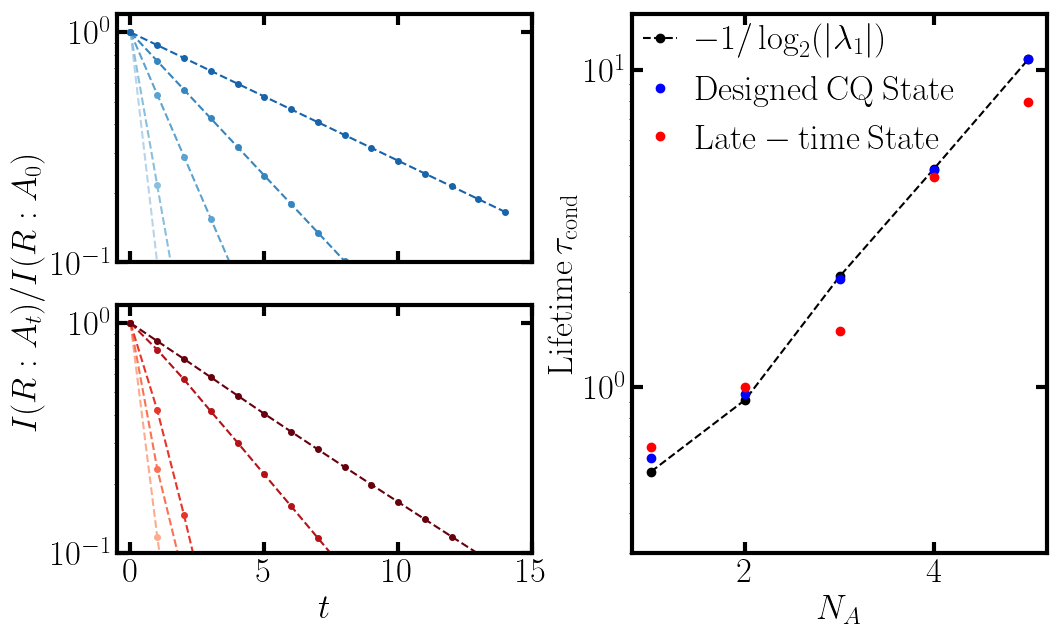

In [160]:
Na = np.arange(1, 6)
Nb = 3

MI = []
for i in range(5):
    each = np.load(f'data/seqModel/Na{Na[i]}/traceout/bellLate/MI_H_Na{Na[i]}Nb{Nb}_traceout.npy')
    MI.append(each)

MI_cq = np.load(f'data/mem_Volterra/CQHInfo_Ising_Nb{Nb}tau50.npy')

fig = plt.figure(figsize=(12, 7))
gs = GridSpec(15, 11, figure=fig)
ax0 = plt.subplot(gs[:7, :5])
ax1 = plt.subplot(gs[8:, :5])
ax2 = plt.subplot(gs[:, 6:])
axs = [ax0, ax1]
blues = plt.cm.Blues(np.linspace(0.3, 0.8, 5))
reds = plt.cm.Reds(np.linspace(0.3, 1, 5))
for i in range(5):
    ax0.plot(MI_cq[i, :15]/MI_cq[i, 0], 'o--', markersize=4, c=blues[i], label=fr'$N_A={Na[i]}$')
    ax1.plot(MI[i][:, 0]/MI[i][0, 0], 'o--', markersize=4, c=reds[i], label=fr'$N_A={Na[i]}$')
# ax0.legend(handlelength=1, framealpha=0, handletextpad=0.5, loc='upper left', bbox_to_anchor=(-0.1, 1.46),
#               ncol=3, columnspacing=1)
for i in range(2):
    axs[i].set_yscale('log')
    axs[i].set_ylim(1e-1, 1.2)
    axs[i].set_xticks(np.arange(4)*5)
    axs[i].set_xlim(-0.5, 15)
    axs[i].tick_params(direction='in', top='on', right='on', length=8, width=3)
ax1.set_xlabel(r'$t$')
ax0.set_xticklabels([])

T1 = [0.6, 0.95, 2.2, 4.85, 10.8] # CQ
T2 = [0.65, 1, 1.5, 4.6, 7.9]
L2 = [0.2780772483903429, 0.4681177073766552, 0.7332064782152298, 0.8675332588154318,
        0.937806913261667]
ax2.plot(Na, -1/np.log2(L2), 'o--', markersize=6, label=r'$-1/\log_2(|\lambda_1|)$', c='k')
ax2.plot(Na, T1, 'o', markersize=6, c='b', label=r'$\rm Designed\: CQ \: State$')
ax2.plot(Na, T2, 'o', markersize=6, c='r', label=r'$\rm Late-time\:State$')
ax2.legend(handlelength=1, framealpha=0, handletextpad=0.5, loc='upper left', bbox_to_anchor=(-0.05, 1.04))
ax2.set_yscale('log')
ax2.set_xlabel(r'$N_A$')
ax2.set_ylabel(r'${\rm Lifetime\:} \tau_{\rm cond}$')
ax2.set_ylim(0.3, 15)
ax2.tick_params(direction='in', top='on', right='on', length=8, width=3)
ax0.text(-4.5, 0.02, r'$I(R:A_t)/I(R:A_0)$', rotation=90)

plt.savefig('figures/uncondQMI_Hlate.svg', bbox_inches='tight')
plt.show()
plt.close()

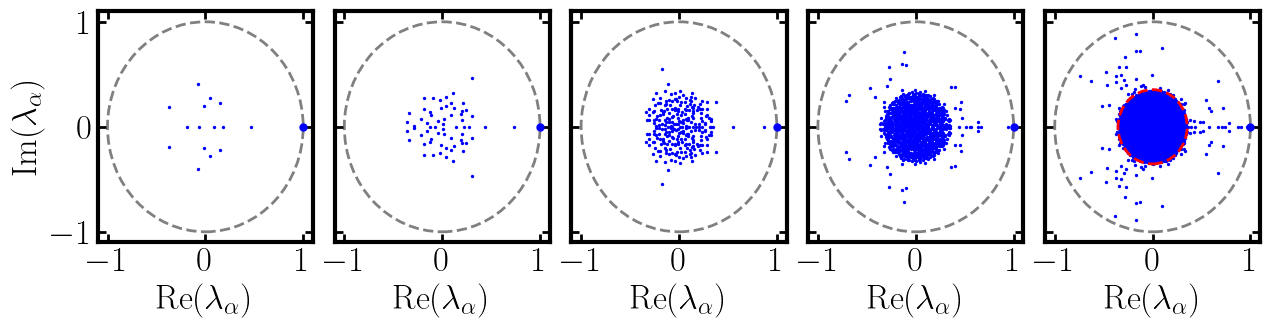

In [3]:
vals = np.load(f'data/mem_Volterra/Teigval_Ising_Nb3tau50.npz')
vals = [vals[f'arr_{i}'] for i in range(6)]

fig, axs = plt.subplots(1, 5, figsize=(15, 3), sharey=True, sharex=True)
for i in range(5):
    axs[i].scatter(np.real(vals[i+1]), np.imag(vals[i+1]), s=2, c='b')
    circ = plt.Circle((0, 0), radius=1, edgecolor='gray', facecolor='None', lw=2, ls='--')
    axs[i].add_patch(circ)
    axs[i].plot(1, 0, 'o', c='b', markersize=5)

    axs[i].set_xlabel(r'${\rm Re}(\lambda_\alpha)$')
    axs[i].tick_params(direction='in', top='on', right='on', length=6, width=2)
circ = plt.Circle((0, 0), radius=1/np.sqrt(2**3), edgecolor='r', facecolor='None', lw=2, ls='--')
axs[-1].add_patch(circ)
axs[0].set_ylabel(r'${\rm Im}(\lambda_\alpha)$')
plt.subplots_adjust(wspace=0.1)

plt.savefig('figures/spectrum_Ising.svg', bbox_inches='tight')
plt.show()
plt.close()

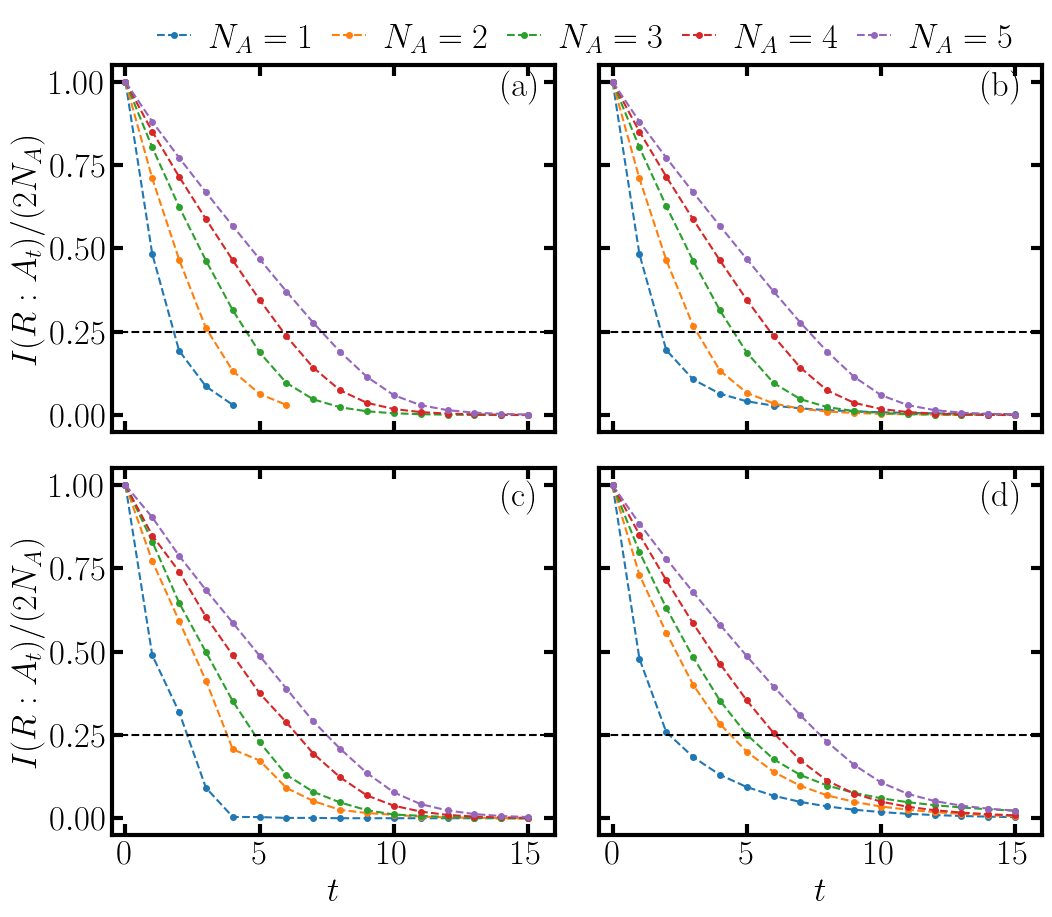

In [ ]:
Na = np.arange(1, 6)
Nb = 1

MI = []
for i in range(5):
    each = np.load(f'data/seqModel/Na{Na[i]}/traceout/bell/MI_Na{Na[i]}Nb{Nb}_traceout.npy')
    MI.append(each)

MI_same = []
for i in range(5):
    each = np.load(f'data/seqModel/Na{Na[i]}/sameU/MI_Na{Na[i]}Nb{Nb}_traceout.npy')
    MI_same.append(each)

MI2 = []
for i in range(5):
    each = np.load(f'data/seqModel/Na{Na[i]}/traceout/bell/MIIsing_Na{Na[i]}Nb{Nb}_traceout.npy')
    MI2.append(each)

MI2_same = []
for i in range(5):
    each = np.load(f'data/seqModel/Na{Na[i]}/sameU/MIIsing_Na{Na[i]}Nb{Nb}_traceout.npy')
    MI2_same.append(each)

fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
for i in range(5):
    axs[0, 0].plot(MI[i].mean(1)/(2*Na[i]), 'o--', markersize=4, 
                   label=fr'$N_A={Na[i]}$')
    axs[0, 1].plot(np.hstack((2*Na[i], MI_same[i].mean(1)))/(2*Na[i]), 'o--', markersize=4, 
                   label=fr'$N_A={Na[i]}$')
    axs[1, 0].plot(np.hstack((2*Na[i], MI2[i]))/(2*Na[i]), 'o--', markersize=4, 
                   label=fr'$N_A={Na[i]}$')
    axs[1, 1].plot(np.hstack((2*Na[i], MI2_same[i]))/(2*Na[i]), 'o--', markersize=4, 
                   label=fr'$N_A={Na[i]}$')
axs[0, 0].legend(handlelength=1, handletextpad=0.5, ncol=5, columnspacing=0.5, loc='upper left',
              bbox_to_anchor=(0.03, 1.2), framealpha=0)
axs[0, 0].set_ylabel(r'$I(R:A_t)/(2N_A)$')
axs[1, 0].set_ylabel(r'$I(R:A_t)/(2N_A)$')
axs[0, 0].set_xlim(-0.5, 16)
#axs[0, 0].set_ylim(-0.05, 1.1)

for i in range(4):
    axs[i//2, i%2].hlines(0.25, xmin=-5, xmax=20, ls='--', color='k')
    axs[i//2, i%2].tick_params(direction='in', top='on', right='on', length=8, width=3)

for i in range(2):
    axs[1, i].set_xlabel(r'$t$')

plt.subplots_adjust(wspace=0.1, hspace=0.1)

fig.text(0.45, 0.85, r'$\rm (a)$')
fig.text(0.85, 0.85, r'$\rm (b)$')
fig.text(0.45, 0.44, r'$\rm (c)$')
fig.text(0.85, 0.44, r'$\rm (d)$')

plt.savefig('figures/uncondQMI_detail.pdf', bbox_inches='tight')
plt.show()
plt.close()

## doped circuit

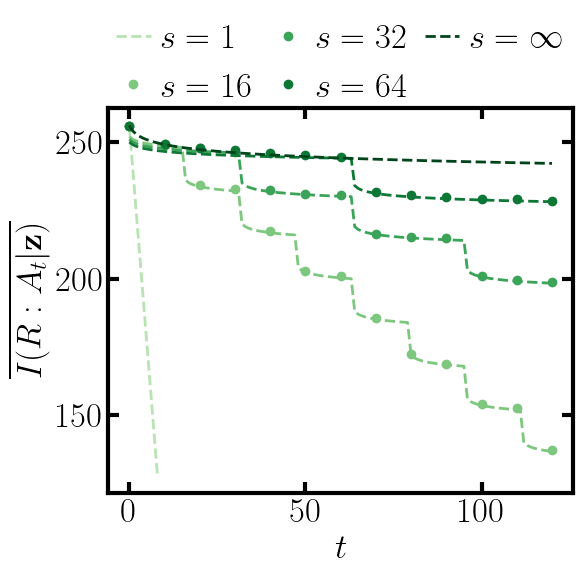

In [53]:
Na = 128
Nb = 16
Nc = 16
s_list = [16, 32, 64]
Ts = np.arange(0, 128, 10)

MIs = np.zeros((len(s_list), len(Ts), 50))
MIs[:, 0] = 2*Na
for i in range(len(s_list)):
    each = np.load(f'data/seqModel/clifford/Na{Na}/monitorDoped/MI_Na{Na}Nb{Nb}Nc{Nc}s{s_list[i]}.npy')
    MIs[i, 1:] = each.mean(2)

fig, ax = plt.subplots(figsize=(6, 5))
greens = plt.cm.Greens(np.linspace(0.3, 1, len(s_list)+2))
t = np.arange(Ts[-1]+1)
ax.plot(np.arange(9), 2*Na - Nc*np.arange(9), '--', lw=2, c=greens[0], label=r'$s=1$')
for i in range(len(s_list)):
    ax.plot(Ts, MIs[i].mean(1), 'o', markersize=6, c=greens[i+1], label=fr'$s={s_list[i]}$')
    n_s = t//s_list[i]
    ax.plot(t, 2*Na - n_s*Nc - np.log2(1+t-s_list[i]*n_s) - np.log2(s_list[i]), '--', lw=2, c=greens[i+1])
ax.plot(t, 2*Na - 2*np.log2(t + 1), '--', lw=2, c=greens[-1], label=r'$s=\infty$')
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$\overline{I(R:A_t|\mathbf{z})}$')
ax.legend(handlelength=1, handletextpad=0.3, framealpha=0, loc='upper left', bbox_to_anchor=(-0.05, 1.3),
          ncol=3, columnspacing=0.5)
ax.tick_params(direction='in', top='on', right='on', length=8, width=3)

plt.savefig('figures/QMI_dope.svg', bbox_inches='tight')
plt.show()
plt.close()

## reset strategy

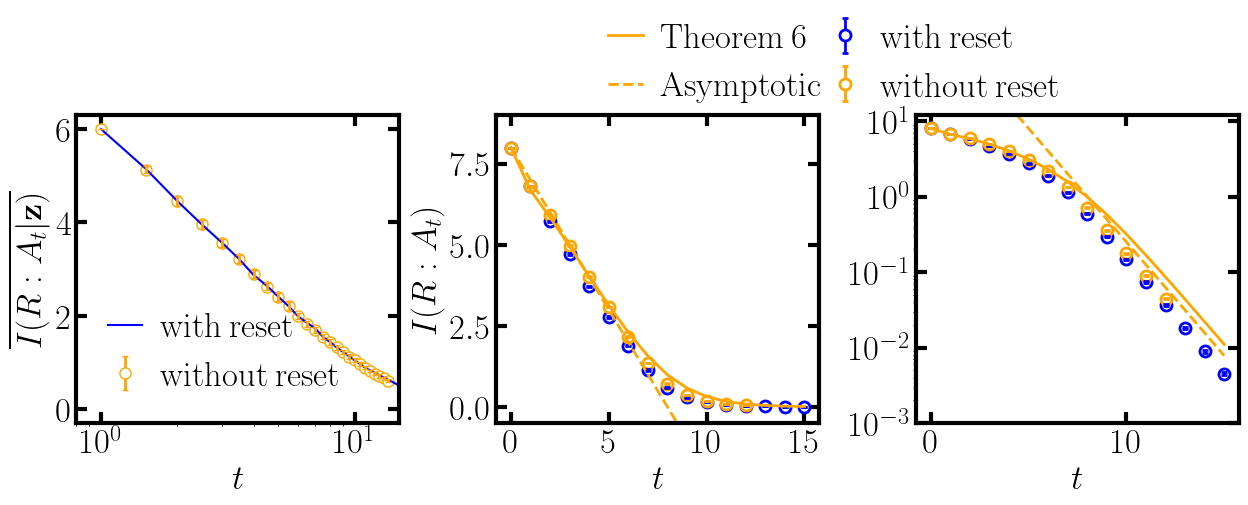

In [20]:
Na1 = 3
Nb = 1
avgMI = np.load(f'data/seqModel/Na{Na1}/monitored/bell/avgMI_Na{Na1}Nb{Nb}.npz')
vnEntropy_wo = np.load(f'data/seqModel/Na{Na1}/noReset/data/vnEntropy_Na{Na1}Nb{Nb}_mc.npy')
avgMI_wo = 2*np.mean(vnEntropy_wo, axis=2)

avgMI_wo_late = np.load(f'data/seqModel/Na{Na1}/noReset/data/vnEntropyLate_Na{Na1}Nb{Nb}_mc.npy')
avgMI_wo_late = 2*np.mean(avgMI_wo_late, axis=2)

Na2 = 4
MI = np.load(f'data/seqModel/Na{Na2}/traceout/bell/MI_Na{Na2}Nb{Nb}_traceout.npy')
MI_wo = np.load(f'data/seqModel/Na{Na2}/noReset/MI_Na{Na2}Nb{Nb}_traceout.npy')

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].plot(avgMI['t']*0.5+1, avgMI['MI'].mean(1), label=r'$\rm with\: reset$', c='b')
axs[0].errorbar(0.5*np.arange(26)+1, np.hstack((2*Na1, avgMI_wo.mean(1))), yerr=np.hstack((0, avgMI_wo.std(1))), barsabove=True,
    fmt='o', mfc='white', markersize=8, elinewidth=2, capsize=2, c='orange', label=r'$\rm without\: reset$')
axs[0].legend(handletextpad=0.5, handlelength=1, framealpha=0, loc='lower left')
axs[0].set_ylabel(r'$\overline{I(R:A_t|\mathbf{z})}$')
axs[0].set_xlabel(r'$(1-1/d_B)t + 1$')
axs[0].set_xscale('log')
axs[0].set_xlim(0.8, 15)

axs[1].errorbar(np.arange(16), MI.mean(1), yerr=MI.std(1), fmt='o', c='b', mfc='white', markersize=8, elinewidth=2, 
            capsize=2, barsabove=True, markeredgewidth=2, label=r'$\rm with\: reset$')
axs[1].errorbar(np.arange(13), MI_wo.mean(1), yerr=MI_wo.std(1), fmt='o', c='orange', 
    mfc='white', markersize=8, elinewidth=2, capsize=2, barsabove=True, markeredgewidth=2, label=r'$\rm without\:reset$')
dA, dB = 2.**Na2, 2.**Nb
t = np.arange(1, 16)
q = (dA**2*dB-1.)/(dA**2* dB**2 - 1.)
MI_wo_th = np.hstack((2*Na2, np.log2((dA**2-1.)*q**t + 1) - np.log2((dA**2-1)*(dB-1)/(dA**2*dB-1)*q**t + 1)))
axs[1].plot(np.arange(16), MI_wo_th, c='orange', lw=2, label=r'$\rm Theorem\:6$')
axs[1].plot(np.arange(16), 2*Na2 - np.arange(16)*Nb, '--', lw=2, c='orange', label=r'$\rm Asymptotic$')
axs[1].set_ylim(-0.5, 9)
axs[1].set_xticks(np.arange(4)*5)
axs[1].legend(handlelength=1, handletextpad=0.5, framealpha=0, loc='upper left', ncol=2, columnspacing=0.2,
    bbox_to_anchor=(0.25, 1.4))
axs[1].set_ylabel(r'$I(R:A_t)$')

axs[2].errorbar(np.arange(16), MI.mean(1), yerr=MI.std(1), fmt='o', c='b', mfc='white', markersize=8, elinewidth=2, 
            capsize=2, barsabove=True, markeredgewidth=2)
axs[2].errorbar(np.arange(13), MI_wo.mean(1), yerr=MI_wo.std(1), fmt='o', c='orange', 
    mfc='white', markersize=8, elinewidth=2, capsize=2, barsabove=True, markeredgewidth=2)
axs[2].plot(np.arange(16), MI_wo_th, c='orange', lw=2)
axs[2].plot(np.arange(16), dA**2. * dB**(-np.arange(16)), '--', lw=2, c='orange')
axs[2].set_ylim(1e-3, 12)
axs[2].set_yscale('log')
for i in range(3):
    axs[i].set_xlabel(r'$t$')
    axs[i].tick_params(direction='in', top='on', right='on', length=8, width=3)

plt.subplots_adjust(wspace=0.3, hspace=0.3)

plt.savefig('figures/reset.svg', bbox_inches='tight')
plt.show()
plt.close()

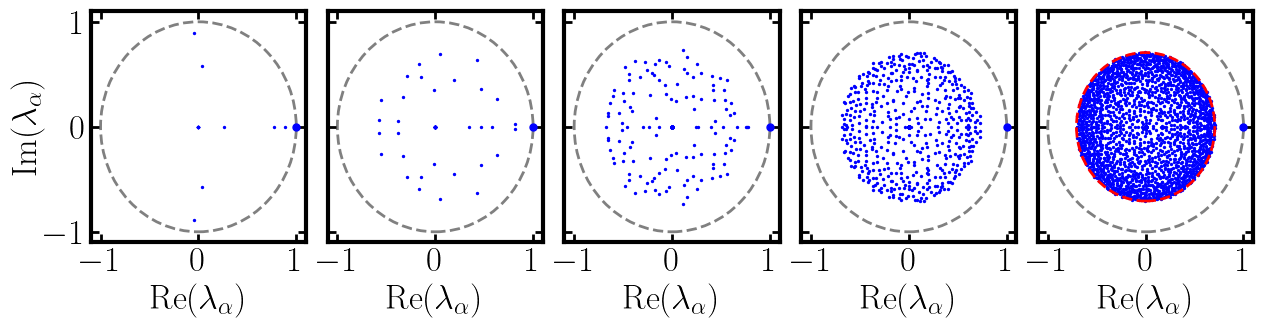

In [5]:
vals = np.load(f'data/mem_Volterra/channelVal_haar_Nb1_noReset.npz')
vals = [vals[f'arr_{i}'] for i in range(5)]

fig, axs = plt.subplots(1, 5, figsize=(15, 3), sharey=True, sharex=True)
for i in range(5):
    axs[i].scatter(np.real(vals[i]), np.imag(vals[i]), s=2, c='b')
    circ = plt.Circle((0, 0), radius=1, edgecolor='gray', facecolor='None', lw=2, ls='--')
    axs[i].add_patch(circ)
    axs[i].plot(1, 0, 'o', c='b', markersize=5)

    axs[i].set_xlabel(r'${\rm Re}(\lambda_\alpha)$')
    axs[i].tick_params(direction='in', top='on', right='on', length=6, width=2)
circ = plt.Circle((0, 0), radius=1/np.sqrt(2), edgecolor='r', facecolor='None', lw=2, ls='--')
axs[-1].add_patch(circ)
axs[0].set_ylabel(r'${\rm Im}(\lambda_\alpha)$', labelpad=-1)
plt.subplots_adjust(wspace=0.1)
plt.savefig('figures/reset_spectrum.svg', bbox_inches='tight')
plt.show()
plt.close()

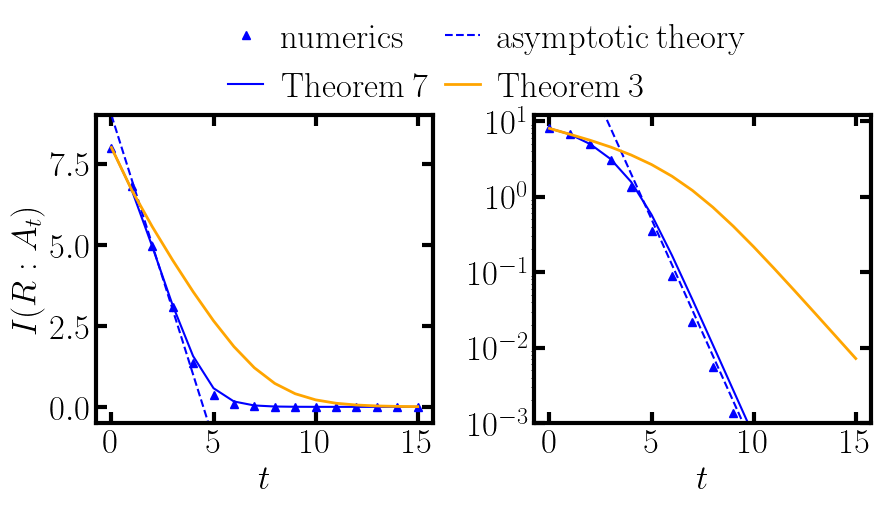

In [ ]:
# fully mixed state reset for unmonitored dynamics
Na2 = 4
Nb = 1
MI_mm = np.load(f'data/seqModel/Na{Na2}/noReset/MI_Na{Na2}Nb{Nb}_traceoutMM.npy')

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(np.hstack((2*Na2, MI_mm.mean(1))), '^', markersize=6, c='b',
    label=r'$\rm numerics$')
axs[0].plot(MIR2_traceout_MM(Na2, Nb, np.arange(16)), c='b', label=r'${\rm Theorem}\:7$')
axs[0].plot(2*Na2 + Nb - 2*Nb * np.arange(6), '--', c='b', label=r'$\rm asymptotic\:theory$')
axs[0].plot(MIR2_traceout(Na2, Nb, np.arange(16)), lw=2, c='orange', label=r'${\rm Theorem}\:3$')
axs[0].set_ylim(-0.5, 9)
axs[0].set_xticks(np.arange(4)*5)
axs[0].legend(handlelength=1, handletextpad=0.5, framealpha=0, loc='upper left', ncol=2, columnspacing=0.5,
    bbox_to_anchor=(0.3, 1.4))
axs[0].set_ylabel(r'$I(R:A_t)$')

axs[1].plot(np.hstack((2*Na2, MI_mm.mean(1))), '^', markersize=6, c='b', 
    label=r'${\rm reset\:by\:} \bm{I}_B/d_B$')
axs[1].plot(MIR2_traceout_MM(Na2, Nb, np.arange(16)), c='b', label=r'${\rm Theorem}\:3$')
axs[1].plot(4**Na2 * 2.**(Nb * (1-2*np.arange(16))), '--', c='b', label=r'$\rm asymptotic\:theory$')
axs[1].plot(MIR2_traceout(Na2, Nb, np.arange(16)), lw=2, c='orange')
axs[1].set_ylim(1e-3, 12)
axs[1].set_yscale('log')
axs[1].set_xticks(np.arange(0, 16, 5))

for i in range(2):
    axs[i].set_xlabel(r'$t$')
    axs[i].tick_params(direction='in', top='on', right='on', length=8, width=3)

plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.savefig('figures/reset_mm.svg', bbox_inches='tight')
plt.show()
plt.close()

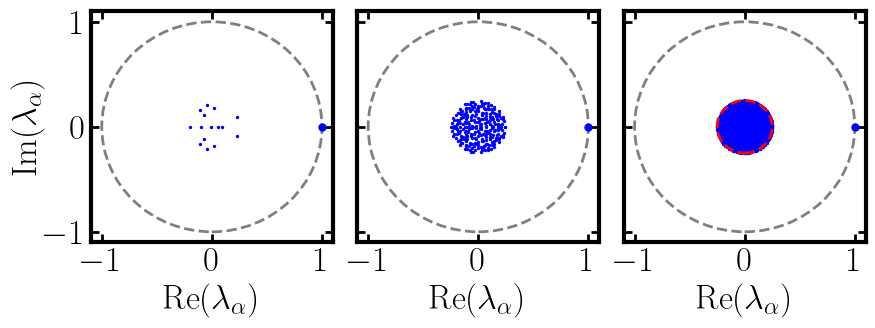

In [21]:
# spectrum of fully-mixed state reset
vals = np.load(f'data/mem_Volterra/channelVal_haarMix_Nb2.npz')
vals = [vals[f'arr_{i}'] for i in range(6)]

fig, axs = plt.subplots(1, 3, figsize=(10, 3), sharey=True, sharex=True)
for i in range(3):
    axs[i].scatter(np.real(vals[2*i+1]), np.imag(vals[2*i+1]), s=2, c='b')
    circ = plt.Circle((0, 0), radius=1, edgecolor='gray', facecolor='None', lw=2, ls='--')
    axs[i].add_patch(circ)
    axs[i].plot(1, 0, 'o', c='b', markersize=5)

    axs[i].set_xlabel(r'${\rm Re}(\lambda_\alpha)$')
    axs[i].tick_params(direction='in', top='on', right='on', length=6, width=2)
circ = plt.Circle((0, 0), radius=1/2**2, edgecolor='r', facecolor='None', lw=2, ls='--')
axs[-1].add_patch(circ)
axs[0].set_ylabel(r'${\rm Im}(\lambda_\alpha)$', labelpad=-1)
plt.subplots_adjust(wspace=0.1)
plt.savefig('figures/reset_spectrum_mm.svg', bbox_inches='tight')
plt.show()
plt.close()

## identical unitary comparison

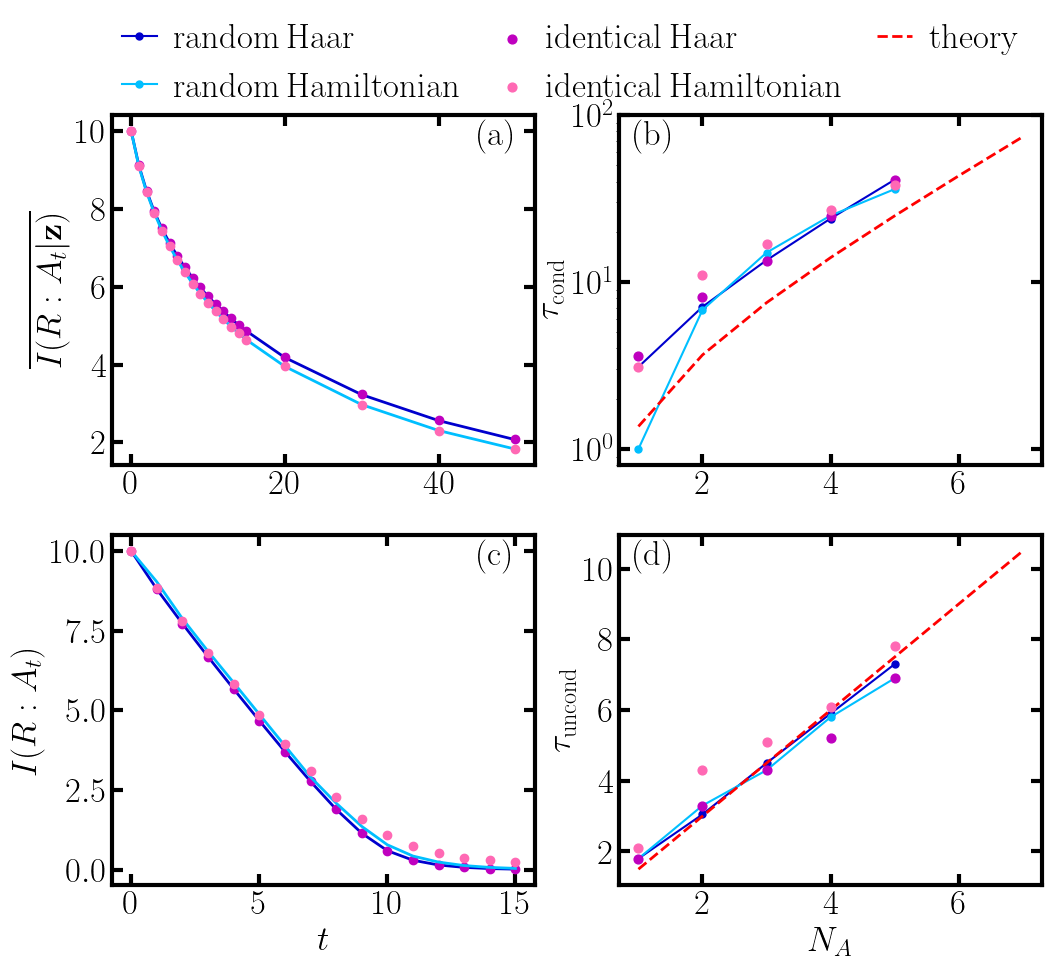

In [ ]:
Na = 5
Nb = 1
avgMI0 = np.load(f'data/seqModel/Na{Na}/sameU/avgMI_Na{Na}Nb{Nb}.npz')
avgMI1 = np.load(f'data/seqModel/Na{Na}/avgMI_Na{Na}Nb{Nb}.npz')

avgMI0_h = np.load(f'data/seqModel/Na{Na}/sameU/avgMIIsing_Na{Na}Nb{Nb}.npz')
avgMI1_h = np.load(f'data/seqModel/Na{Na}/sameU/avgMIIsing_Na{Na}Nb{Nb}.npz')

MI0 = np.load(f'data/seqModel/Na{Na}/sameU/MI_Na{Na}Nb{Nb}_traceout.npy')
MI1 = np.load(f'data/seqModel/Na{Na}/traceout/MI_Na{Na}Nb{Nb}_traceout.npy')

MI0_h = np.load(f'data/seqModel/Na{Na}/sameU/MIIsing_Na{Na}Nb{Nb}_traceout.npy')
MI1_h = np.load(f'data/seqModel/Na{Na}/traceout/MIIsing_Na{Na}Nb{Nb}_traceout.npy')

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs[0, 0].plot(avgMI1['t'][:-2], avgMI1['MI'].mean(1)[:-2], lw=2, c='mediumblue')
axs[0, 0].plot(avgMI0['t'], avgMI0['MI'].mean(1), 'o', c='m', markersize=6)
axs[0, 0].plot(avgMI1_h['t'][:-2], avgMI1_h['MI'][:-2], lw=2, c='deepskyblue')
axs[0, 0].plot(avgMI0_h['t'][:-2], avgMI0_h['MI'][:-2], 'o', c='hotpink', markersize=6)
axs[0, 0].set_ylabel(r'$\overline{I(R:A_t|\mathbf{z})}$')

Tc0 = [3.6, 8.1, 13.4, 25, 41]
Tc1 = [3.1, 7.1, 13.5, 24, 41]
Tc0_h = [3.1, 11, 16.9, 27, 38]
Tc1_h = [1, 6.8, 15, 25, 36]
axs[0, 1].plot(np.arange(1, 6), Tc1, 'o-', c='mediumblue', markersize=5, label=r'$\rm random\:Haar$')
axs[0, 1].plot(np.arange(1, 6), Tc1_h, 'o-', c='deepskyblue', markersize=5, label=r'$\rm random\:Hamiltonian$')
axs[0, 1].scatter(np.arange(1, 6), Tc0, c='m', s=40, zorder=5, label=r'$\rm identical\:Haar$')
axs[0, 1].scatter(np.arange(1, 6), Tc0_h, c='hotpink', s=40, zorder=5, label=r'$\rm identical\:Hamiltonian$')
axs[0, 1].plot(np.arange(1, 8), 2**Nb*(2.**((1-0.25)*np.arange(1, 8)) - 1)/(2**Nb-1), 
    '--', lw=2, c='r', label=r'$\rm theory$')
axs[0, 1].set_yscale('log')
axs[0, 1].set_ylim(0.8, 100)
axs[0, 1].set_ylabel(r'$\tau_{\rm cond}$')
axs[0, 1].legend(handlelength=1, handletextpad=0.5, ncol=3, columnspacing=1, loc='upper left',
                 bbox_to_anchor=(-1.25, 1.35), framealpha=0)

axs[1, 0].plot(np.hstack((2*Na, MI1.mean(1))), lw=2, c='mediumblue')
axs[1, 0].plot(np.hstack((2*Na, MI0.mean(1))), 'o', c='m', markersize=6)
axs[1, 0].plot(np.hstack((2*Na, MI1_h)), lw=2, c='deepskyblue')
axs[1, 0].plot(np.hstack((2*Na, MI0_h)), 'o', c='hotpink', markersize=6)
axs[1, 0].set_xlabel(r'$t$')
axs[1, 0].set_ylabel(r'$I(R:A_t)$')

Tc0 = [1.8, 3.3, 4.3, 5.2, 6.9]
Tc1 = [1.8, 3.05, 4.5, 5.9, 7.3] # epsilon = 0.25
Tc0_h = [2.1, 4.3, 5.1, 6.1, 7.8]
Tc1_h = [1.8, 3.3, 4.3, 5.8, 6.9]

axs[1, 1].plot(np.arange(1, 6), Tc1, 'o-', c='mediumblue', markersize=5)
axs[1, 1].plot(np.arange(1, 6), Tc1_h, 'o-', c='deepskyblue', markersize=5)
axs[1, 1].scatter(np.arange(1, 6), Tc0, c='m', s=40, zorder=5)
axs[1, 1].scatter(np.arange(1, 6), Tc0_h, c='hotpink', s=40, zorder=5)
axs[1, 1].plot(np.arange(1, 8), 2*(1-0.25)*np.arange(1, 8)/Nb, '--', lw=2, c='r')
axs[1, 1].set_xlabel(r'$N_A$')
axs[1, 1].set_ylabel(r'$\tau_{\rm uncond}$')

for i in range(4):
    axs[i//2, i%2].tick_params(direction='in', top='on', right='on', length=8, width=3)

fig.text(0.43, 0.85, r'$\rm (a)$')
fig.text(0.56, 0.85, r'$\rm (b)$')
fig.text(0.43, 0.43, r'$\rm (c)$')
fig.text(0.56, 0.43, r'$\rm (d)$')

plt.savefig('figures/id_unitary.pdf', bbox_inches='tight')
plt.show()
plt.close()

# MFIM

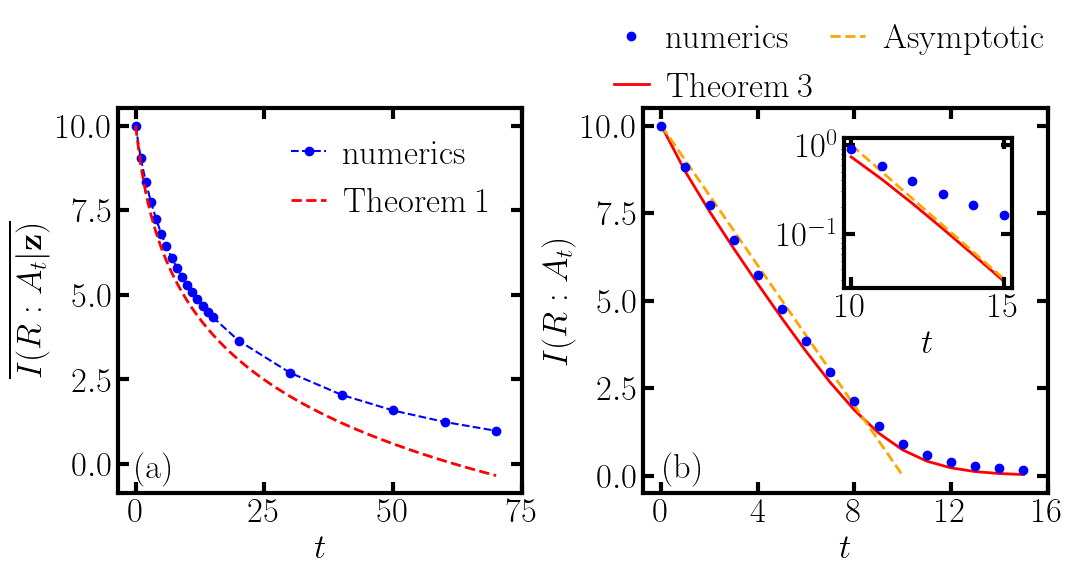

In [90]:
Na = 5
Nb = 1

avgMI = np.load(f'data/seqModel/Na{Na}/monitored/avgMIMFIM_Na{Na}Nb{Nb}.npz')
MI = np.load(f'data/seqModel/Na{Na}/traceout/bell/MIMFIM_Na{Na}Nb{Nb}_traceout.npy')


t = np.arange(71)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(avgMI['t'], avgMI['MI'], 'o--', c='b', markersize=6, label=r'$\rm numerics$')
axs[0].plot(t, 2*Na - 2*np.log2(1+(1-1/2.**Nb)*t), '--', c='r', lw=2, label=r'$\rm Theorem\:1$')
axs[0].legend(handlelength=1, handletextpad=0.5, framealpha=0)
axs[0].set_ylabel(r'$\overline{I(R:A_t|\mathbf{z})}$')
axs[0].set_xlabel(r'$t$')
axs[0].set_xticks(np.arange(4)*25)

axs[1].plot(MI, 'o', c='b', markersize=6, label=r'$\rm numerics$')
axs[1].plot(MIR2_traceout(Na, Nb, np.arange(16)), lw=2, c='r', label=r'$\rm Theorem\:3$', zorder=1)
axs[1].plot(2*Na - np.arange(11)*Nb, '--', lw=2, c='orange', label=r'$\rm Asymptotic$', zorder=1)
axs[1].legend(handlelength=1, handletextpad=0.5, framealpha=0, loc='upper left', bbox_to_anchor=(-0.15, 1.3),
              ncol=2, columnspacing=0.5)
axs[1].set_ylabel(r'$I(R:A_t)$')
axs[1].set_xlabel(r'$t$')
axs[1].set_xticks(np.arange(5)*4)

inset = fig.add_axes([0.73, 0.52, 0.14, 0.3])
inset.plot(np.arange(10, 16), MI[10:], 'o', c='b', markersize=6)
inset.plot(np.arange(10, 16), MIR2_traceout(Na, Nb, np.arange(10, 16)), lw=2, c='r', label=r'$\rm Theorem\:3$', zorder=1)
inset.plot(np.arange(10, 16), 4.**Na * 2.**(-Nb*np.arange(10, 16)), '--', lw=2, c='orange', label=r'$\rm Asymptotic$', zorder=1)
inset.set_yscale('log')
inset.tick_params(direction='in', top='on', right='on', length=8, width=3)
inset.set_xlabel(r'$t$')

for i in range(2):
    axs[i].tick_params(direction='in', top='on', right='on', length=8, width=3)

plt.subplots_adjust(wspace=0.3)
fig.text(0.14, 0.14, r'$\rm (a)$')
fig.text(0.58, 0.14, r'$\rm (b)$')

plt.savefig('figures/MI_MFIM.pdf', bbox_inches='tight')
plt.show()
plt.close()